In [1]:
import numpy as np
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2


In [2]:
import numpy as np
from tqdm import tqdm
import time
from numba import njit, prange

# 1. Spatial Impulse Response (SIR) of far-field rectangular apertures : The Tupholme - Stephanishen approach.

Placing the rectangular aperture $ m $ of width and height $ w_{mx}, w_{my} $ in the $ x\text{-}y $ plane with its center at the coordinate $ \vec{r}_m $, the field point position vector—from the \( m \)-th rectangle to the \( p \)-th field point—is

$$
\vec{r}_{(m,p)} = \vec{r}_p - \vec{r}_m
$$

where $ \vec{r}_p $ are the coordinates of the field point. This vector can be further decomposed into a distance

$$
l_{(m,p)} = \| \vec{r}_{(m,p)} \|
$$

and a unit vector

$$
\vec{u}_{(m,p)} = \frac{\vec{r}_{(m,p)}}{\| \vec{r}_{(m,p)} \|} = (x_u, y_u, z_u)
$$

Using this description, one can get the following equations:

$$
\begin{align*}
t_1 &= \frac{l_{(m,p)}}{c_0} - \frac{\Delta t_1 + \Delta t_2}{2} \\
t_2 &= t_1 + \Delta t_1 \\
t_3 &= t_1 + \Delta t_2 \\
t_4 &= t_1 + \Delta t_1 + \Delta t_2 \tag{13}
\end{align*}
$$

Where $ \Delta t_1 $ and $ \Delta t_2 $ correspond to the minimum and maximum time-of-flight (TOF) for the side lengths of the rectangle:

$$
\Delta t_1 = \min\left(\frac{w_{my} y_u}{c_0}, \frac{w_{mx} x_u}{c_0}\right) \tag{14}
$$

$$
\Delta t_2 = \max\left(\frac{w_{my} y_u}{c_0}, \frac{w_{mx} x_u}{c_0}\right) \tag{15}
$$

Note that $ t_2 - t_1 = t_4 - t_3 = \Delta t_1 $ and $ t_3 - t_2 = \Delta t_2 - \Delta t_1 $, and that there are some cases where some of the $ t $'s are identical and thus have $ \Delta t_1 $ and/or $ \Delta t_2 $ equal to zero.

The shape of the trapezoid is a function of $ \Delta t_1 $ and $ \Delta t_2 $ and so is its amplitude, but the area of the trapezoid integrated over the whole time interval is always equal to:

$$
a_{rec}(l) = \frac{w_{mx} w_{my}}{2\pi l_{(m,p)}} \tag{16}
$$

Geometrically, the area can also be expressed as

$$
a_{rec} = h_{max} \Delta t_2 \tag{17}
$$

Combining (16) and (17) gives the trapezoid amplitude:

$$
h_{(m,p)}^{plateau} = \frac{w_{mx} w_{my}}{2\pi \Delta t_2 l_{(m,p)}} \tag{18}
$$

Then, the far-field trapezoidal SIR for an $ m $-th rectangular aperture is described by

$$
h_m(\vec{r}_p, t) = h(\vec{u}_{(m,p)}, l_{(m,p)}, w_{mx}, w_{my}, t) =
\begin{cases}
s_{(m,p)} (t - t_1), & t_1 < t < t_2 \\
h_{(m,p)}^{plateau}, & t_2 < t < t_3 \\
s_{(m,p)} (t_4 - t), & t_3 < t < t_4 \\
0, & \text{elsewhere}
\end{cases}
\tag{19}
$$

with

$$
s_{(m,p)} = \frac{h_{(m,p)}^{plateau}}{\Delta t_1} \tag{20}
$$

So, with the informations of the 5 parameteres we can compute all SIR of each small rectangle that composes the transducer. 
Now we are going to create a function to visualize the contribution of each small subdivision.


# 2. Methods for computation of transducer SIR

The last trapezoidal SIR for each small rectangle is valid just if the subdivisions that are in far-field condition, then they must meet the next condition

$$
w \ll \sqrt{\frac{4 l c_0 }{f}} \tag{21}
$$

Where $l$ is the distance to the field point, $w$ the largest dimension of the rectangle and $f$ is the highest frequency in the response simulated. 

Thus, if this condition is guaranteed, thanks to the linearity assumption, we can obtain the next expression for the Transducer SIR shape.

$$
h_{tx}(\vec{r}_p, t) \approx \sum_{m=1}^{M} a_m \, h_m(\vec{r}_p, t - \tau_m) \tag{22}
$$

Where $h_m$ corresponds to the SIR showed in eq.[19], and $a_m, \tau_m$ corresponds to the apodization and delay applied to that specific patch. 
Therefore, to compute the transducer SIR, we need to add up each small patch $m$ SIR, of the $M$ patches making up the transducer.

## 2.1. Visualization of the methods.

In this 2nd section, we describe the Naive and the Sparse Delta Integration (SDI) methods.

The naive method loops over the range of time where the trapezoidal piecewise function is defined, from $t_1$ to $t_4$, filling all non-zero trapezoid values per patch. In contrast, the proposed SDI method rewrites the trapezoid shape as the double integration of Dirac delta distributions—the complete development will be explained in the next subsection. This mathematical trick allows us, instead of looping over all time samples within $[t_1, t_4]$ for each patch, to compute only 8 sample points (for discrete implementation, 8 deltas are needed instead of 4) for all patches, at the expense of a double integration on time after looping all patches. To give a glimpse of the methods, the next GUI has as its objective to let you play with a simple trapezoid and the parameters that define it.

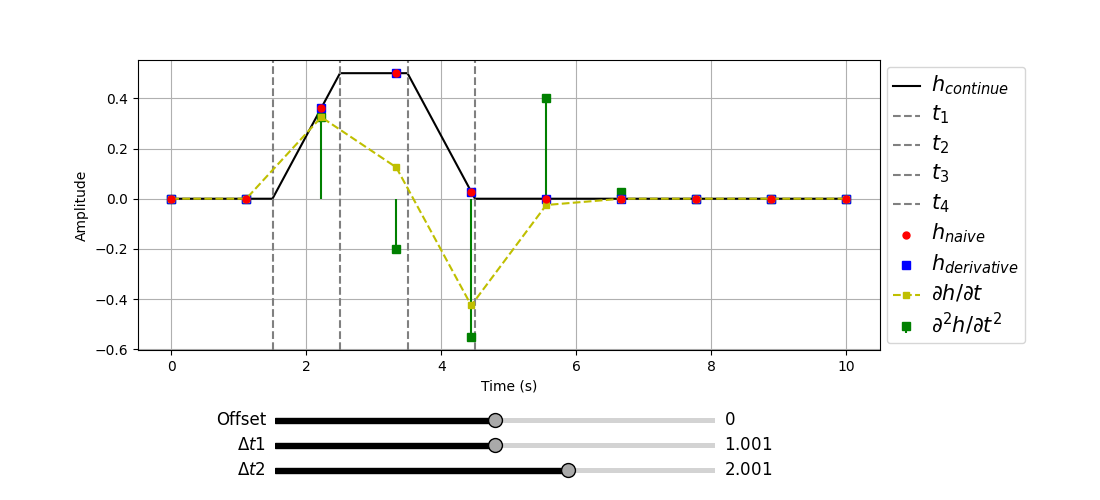

In [3]:
%matplotlib widget
from trapezoid_method_visualization import plot_trapezoid_methods

area = 1
l_c = 3

# Initial parameters and its range
Dt1 = 1
Dt2 = 2
shift = 0
range_Dt1 = (0.001, 2)
range_Dt2 = (0.001, 3)
range_shift = (-1, 1)

plot_trapezoid_methods(
    area, l_c, Dt1, Dt2, shift, range_Dt1, range_Dt2, range_shift
)

In [4]:
plt.close()
%matplotlib inline

## 2.2. Patches' SIR visualization

From the development showed in section 1, we can start to define the function we'll need to compute the trapezoids.

In [5]:
inv_2pi = 1/(2*np.pi)

# ---------- small helper (njit) for rectangle SIR parameters ----------
@njit
def compute_rectangle_SIR_params(wx, wy, dx, dy, dist, inv_c, apod, delay, dt):
    """
    Return t1,t2,t3,t4,h_max (float32).
    dx,dy are direction cosines (xp, yp) used in your original compute.
    dist is distance from patch center to field point (float).
    inv_c is 1/c (float).
    """
    xp_abs = abs(dx) * wx * inv_c
    yp_abs = abs(dy) * wy * inv_c
    # enforce minimum to avoid zero width
    Dt1 = min(xp_abs, yp_abs)
    Dt2 = max(xp_abs, yp_abs)
    if Dt1 < dt:
        Dt1 = dt
    if Dt2 < dt:
        Dt2 = dt

    area = (wx * wy * inv_2pi) / dist
    # time-of-flight base
    t1 =  dist * inv_c - 0.5 * (Dt1 + Dt2) + delay
    t2 = t1 + Dt1
    t3 = t1 + Dt2
    t4 = t1 + Dt1 + Dt2
    h_max = area / Dt2 * apod

    return t1, t2, t3, t4, h_max


To see how this would like for a certain transducer geometry, let create a function that will compute al these events in function of field point and patches of the transducer as follows

In [6]:
@njit(parallel=True)
def compute_all_events(P, M, pts, centers, wx, wy, c, apods, delays, events, dt):
    for p in prange(P):
        for i in range(M):
            dx = pts[p, 0] - centers[i, 0]
            dy = pts[p, 1] - centers[i, 1]
            dz = pts[p, 2] - centers[i, 2]
            dist = np.sqrt(dx * dx + dy * dy + dz * dz)

            xp, yp = dx / (dist), dy / (dist)
            t1, t2, t3, t4, h_max = compute_rectangle_SIR_params(
                wx,
                wy,
                xp,
                yp,
                dist,
                1/c,
                apods[i],
                delays[i],
                dt,
            )
            events[p, i, 0] = t1
            events[p, i, 1] = t2
            events[p, i, 2] = t3
            events[p, i, 3] = t4
            events[p, i, 4] = h_max

To create the transducer, we are going to use some predefined functions from the package. If you are looking for more information on how to use and define transducer objects, please refer to the Tutorial_PyField.

Let's create a linear array with 128 elements and no subdivision to make it easier. Note that if no subdivision is done, the far-field condition of the trapezoidal spatial impulse response (SIR) may not be met, and therefore our pressure field is not well simulated. However, we'll continue like this just for pedagogic purposes.

LinearArrayTransducer initialized in 0.0000 seconds.


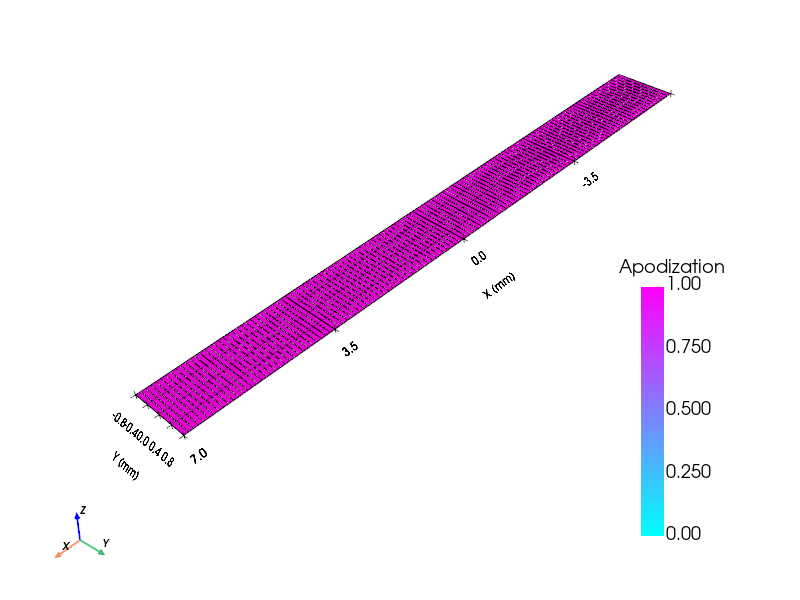

In [7]:
import pysonogen.transducers as transducers

# Create transducer with elevation focus
n_elements = 128
pitch_mm = 0.11
element_width_mm = 0.108
element_height_mm = 1.5
tx_freq = 12.5  # MHz
elevation_focus_mm = 0 #8  # mm
sub_x = 1
sub_y = 1

MyTransducer = transducers.LinearArrayTransducer(
    n_elements         = n_elements,
    element_width_mm   = element_width_mm,
    element_height_mm  = element_height_mm,
    elevation_focus_mm = elevation_focus_mm,
    kerf_mm            = pitch_mm - element_width_mm,
    no_sub_x           = sub_x,
    no_sub_y           = sub_y,
    frequency_Hz       = tx_freq*1e6,  # MHz),
    )

MyTransducer.show(notebook = True, jupyter_backend='static')

From this object we are going to take the variable to input in our function that computes all the events (patches - field point combinations):

In [8]:
def compute_sub_elem_params(MyTransducer):
    centers, apods, delays = [], [], []
    for elem in range(MyTransducer.n_elements):
        for sub_elem in range(MyTransducer.no_sub_x * MyTransducer.no_sub_y):
            verts = MyTransducer.sub_quad_verts[
                elem * (MyTransducer.no_sub_x * MyTransducer.no_sub_y) + sub_elem
            ]
            centers.append(verts.mean(axis=0))
            apods.append(MyTransducer.apodization[elem])
            delays.append(MyTransducer.delays[elem])

    centers = np.array(centers, dtype=np.float32)  # shape (M, 3)
    apods = np.array(apods, dtype=np.float32)  # shape (M,)
    delays = np.array(delays, dtype=np.float32)  # shape (M,)
    return centers, apods, delays

In [9]:
# SIR Parameters

f_sampling = 200e6  # Hz
dt = 1 / f_sampling  # s
field_point_mm = np.array([[3, 0, 8]])  # mm
c = 1540  # speed of sound (m/s)

# Transducer geometry parameters
# Lets compute the patch parameters

wx = MyTransducer.elem_width  # element width (m)
wy = MyTransducer.elem_height  # element height (m)
# apodization and delays saved in the transducer object
apod_zeros = MyTransducer.apodization
delay_zeros = MyTransducer.delays
# compute the sub-element parameters
centers, apods_sub_zeros, delays_sub_zeros = compute_sub_elem_params(MyTransducer)
# compute how the trapezoid would look like with apodization and delays
delay_focus = MyTransducer.compute_delays(focus_mm=field_point_mm)
apod_focus = MyTransducer.compute_apodization(focus_mm=field_point_mm, FoverD = 1, apodization_type='hamming')
centers, apods_sub_focus, delays_sub_focus = compute_sub_elem_params(MyTransducer)

# Let's compute the events for a single field point and all patches of the transducer
P = field_point_mm.shape[0]  # number of field points
M = centers.shape[0]  # number of patches

pts = field_point_mm * 1e-3  # (P,3) array of field points (m)
events_wo_apod_delays = np.zeros((P, M, 5), dtype=np.float32)  # (P,M,5) array of events
events_w_apod_delays = np.zeros((P, M, 5), dtype=np.float32)  # (P,M,5) array of events
print("events shape:", events_wo_apod_delays.shape)

events shape: (1, 128, 5)


In [10]:
compute_all_events(P, M, pts, centers, wx, wy, c, apods_sub_zeros, delays_sub_zeros, events_wo_apod_delays, dt)
compute_all_events(P, M, pts, centers, wx, wy, c, apods_sub_focus, delays_sub_focus, events_w_apod_delays, dt)


And let's create a function to visualize how each event look like

In [11]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def plot_SIR_events(events, y_subdiv, *, ax = None,title = None, cmap = None, add_cbar = True):

    if title is None :
        title = f'Contribution of each element to the field point at {field_point_mm[0]} mm'
    # Plot the contribution of each element to the field point

    # Add a colorbar
    n_elements = events.shape[1] // y_subdiv  # Correct calculation
    if cmap is None:
        cmap = plt.get_cmap('jet')
    else:
        cmap = plt.get_cmap(cmap)

    colors = cmap(np.linspace(0, 1, n_elements))
        
    flag_return_ax = True
    if ax is None:
        flag_return_ax = False
        fig, ax = plt.subplots(figsize=(14, 4))


    for i in range(n_elements):
        for j in range(y_subdiv): # loop over subdivisions in elevation
            m = j + i*y_subdiv
            t1, t2, t3, t4, h_max = events[0, m,:]
            ax.plot([t1*1e6, t2*1e6], [0, h_max], color=colors[i], lw=2, linestyle='solid')
            ax.plot([t2*1e6, t3*1e6], [h_max, h_max], color=colors[i], lw=2, linestyle='solid')
            ax.plot([t3*1e6, t4*1e6], [h_max, 0], color=colors[i], lw=2, linestyle='solid')
    ax.set_xlabel('Time (µs)')
    ax.set_ylabel('SIR (a.u.)')
    # ax.set_yscale('log')
    ax.set_title(title, loc='left')  # --- IGNORE ---
    ax.grid()

    if add_cbar:
        # Create colorbar as a legend inside the figure
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=n_elements))
        sm.set_array([])
        # Place the colorbar as an inset box (adjust location and size as needed)
        cax = inset_axes(ax, width="40%", height="8%", loc='upper right', borderpad=2)
        cbar = plt.colorbar(sm, cax=cax, orientation='horizontal')
        cbar.set_label('Element Index')
        cbar.set_ticks([0, n_elements//2, n_elements])
        cbar.set_ticklabels([0, n_elements//2, n_elements])
            
        cbar.ax.xaxis.set_label_position('top')

    if flag_return_ax:
        return ax

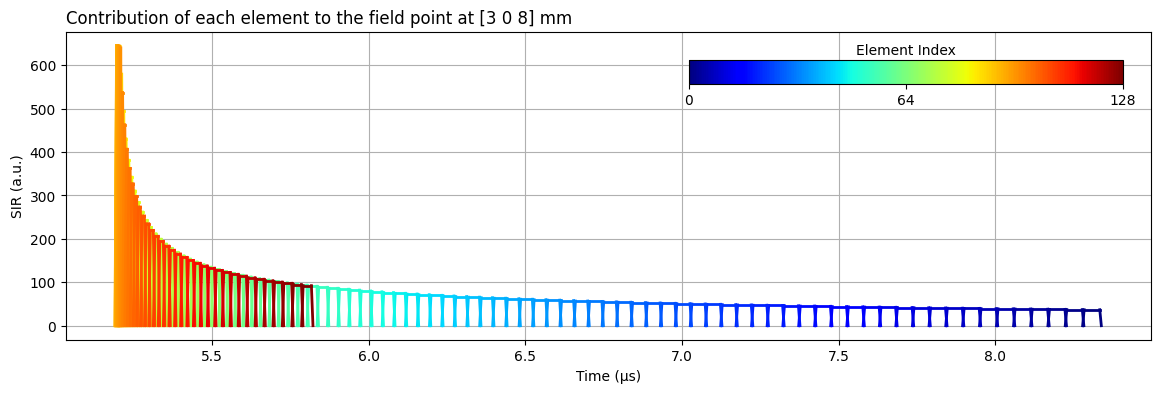

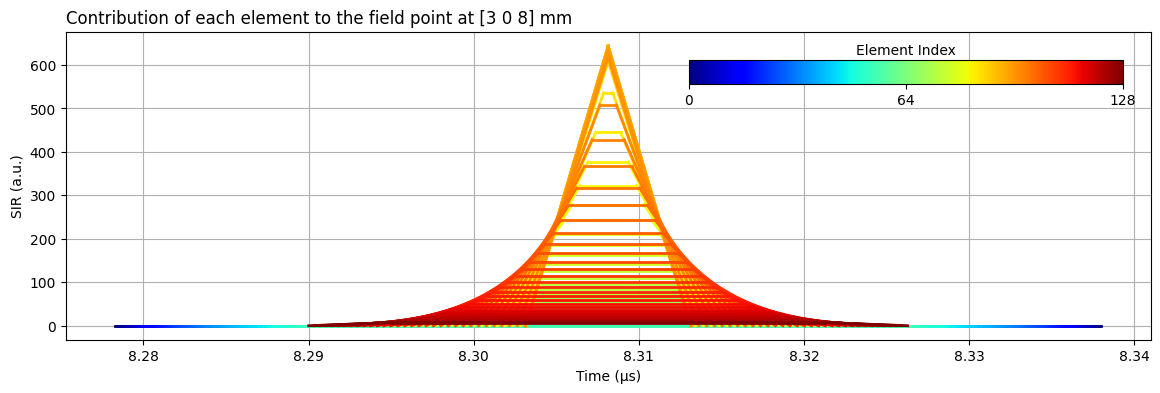

In [12]:
cmap = 'jet'

colormap = plt.get_cmap(cmap)

elem_colors = colormap(np.linspace(0, 1, n_elements))

plot_SIR_events(events_wo_apod_delays, sub_y, cmap = cmap)
plot_SIR_events(events_w_apod_delays, sub_y, cmap = cmap)


To compute the final shape of the transducers SIR, one need tu sum the contribution of each of the trapezoids showed in the last figure.

## 2.2. Naive method

The naive approach is the direct one, where one would loop over the timegrid vector to add for each point and patch the contributions. So the function would look as something like this.

In [13]:
# for a point p, element m, we have event = (t1, t2, t3, t4, h_max)
# we want to compute h_out[p, k] += h(t) where t = time_grid[k]
# and h(t) is the trapezoid defined by event
# k_start and k_end define the range of time samples to consider for this event

@njit
def naive_method(t1, t2, t3, t4, h_max, time_grid, h_out, p, k_start, k_end):
    slope = h_max / (t2 - t1)  # slope of rising and falling edges    

    # loop over every sample that might see part of this trapezoid
    for k in range(k_start, k_end):
        t = time_grid[k]
        # evaluate continuous trapezoid h(t)
        if t < t1 or t > t4:
            continue
        elif t < t2:
            h = slope * (t - t1) 
        elif t < t3:
            h = h_max
        else:
            h = slope * (t4 - t)

        # accumulate
        h_out[p, k] += h

## 2.3. Sparse Delta Integration (SDI)

From the derivation on equation [19], we can see that the first derivative of the trapezoid piecewise function can be written as follows:

$$
\frac{\partial h_m(\vec{r}_p, t)}{\partial t} =
\begin{cases}
s_{(m,p)}, & t_1 < t < t_2 \\
-s_{(m,p)}, & t_3 < t < t_4 \\
0, & \text{elsewhere}
\end{cases}
= s_{(m,p)} \cdot \left[ u(t-t_1) - u(t-t_2) - u(t-t_3) + u(t-t_4) \right]
\tag{24}
$$

Where $s_{(m,p)}$ is a function of the $m$-patch geometry and the field point $p$ as depicted in equation 20, and $u(t)$ is the Heaviside step function, defined as

$$
u(t) =
\begin{cases}
1, & t \geq 0 \\
0, & t < 0
\end{cases}
$$

If we continue with further derivation, we get the next expression:

$$
\frac{\partial^2 h_m(\vec{r}_p, t)}{\partial t^2} = s_{(m,p)} \cdot \left[ \delta(t-t_1) - \delta(t-t_2) - \delta(t-t_3) + \delta(t-t_4) \right] = s_{(m,p)} \Delta\delta(t)
\tag{25}
$$

Where $\delta(t)$ stands for the unit impulse or Dirac delta distribution, defined as

$$
\delta(t) =
\begin{cases}
1, & t = 0 \\
0, & t \neq 0
\end{cases}
$$
And

$$
\Delta\delta(t) = \delta(t-t_1) - \delta(t-t_2) - \delta(t-t_3) + \delta(t-t_4)
\tag{30}
$$

Thus, we can rewrite the piecewise function shown in [19] as

$$
h_{e,m}(\vec{r}_p, t) = \int_{-\infty}^{t}  \int_{-\infty}^{t'} s_{(m,p)} \Delta\delta(t'') \, dt''  dt'
\tag{26}
$$

Thanks to the additive property of the integrals, the SIR for a transducer composed of $M$ patches becomes

$$
h_{tx}(\vec{r}_p, t) \approx \sum_{m_e}^{M} a_e h_{e,m}(\vec{r}_p, t - \tau_e) = \int_{-\infty}^{t}  \int_{-\infty}^{t'} \left[\sum_{m_e}^{M}  a_e s_{(m,p)} \Delta\delta(t''  - \tau_e) \right] dt''  dt'
\tag{27}
$$


For implementation, the temporal axis must be discretized, which requires careful handling of the delta function contributions. The continuous variable $t$ is replaced by its sampled version $\{ t_k \}$, a vector of $T$ samples as defined in Eq. [24]. Unlike the piecewise trapezoidal function defined by the four times $(t_1, t_2, t_3, t_4)$, the reformulated method uses delta functions located exactly at these times. Since $t_1, \ldots, t_4$ do not necessarily coincide with the discrete grid $\{ t_k \}$, their contributions must be distributed to the closest discrete samples.

Intuitively, this means that instead of placing a delta “between samples” (which would be lost on the grid), we split its weight between the two nearest time samples. This ensures that the total contribution is preserved while being consistent with the discrete representation. Formally, given a continuous time $t' \in \mathbb{R}$, its index position in the sampled grid is

$$
k_{t'} = \frac{t' - t_0}{dt}
\tag{28}
$$

Here $k_{t'} \in \mathbb{R}$, while $k \in \mathbb{Z}^+$ represents valid discrete indices. Thus, instead of assigning the delta exactly at $t'$, its amplitude is distributed between the two nearest discrete grid points, using linear weights:

$$
w^f(t') = k_{t'} - \lfloor k_{t'} \rfloor, \qquad w^c(t') = \lceil k_{t'} \rceil - k_{t'} = w^f(t') + 1
\tag{29}
$$

Where now $\lfloor k_{t'} \rfloor \in \mathbb{Z}^+$ and $\lceil k_{t'} \rceil \in \mathbb{Z}^+$, and correspond to the floor and ceil value of the number $k_{t'}$ that can now be used as index. Then, for taking the lower and higher value between $\{ t_k \}$ closest to $t'$, we define

$$
t^f = t_{\lfloor k_t \rfloor}, \qquad t^c = t_{\lceil k_t \rceil}
\tag{30}
$$

Where $t_{\lfloor k_{t'} \rfloor}$ means that we are evaluating our time vector at the index $\lfloor k_{t'} \rfloor$, and the same for $\lceil k_t \rceil$. With this interpolation, the discrete version of the deltas defined in equation [29] becomes

$$
\Delta\delta(t_k) = \Delta\delta(t_k)^{\text{ceil}} + \Delta\delta(t_k)^{\text{floor}}
\tag{31}
$$

With

$$
\Delta\delta(t_k)^{\text{floor}} = w^f(t_1) \delta(t_k - t_1^f) - w^f(t_2) \delta(t_k - t_2^f) - w^f(t_3) \delta(t_k - t_3^f) + w^f(t_4) \delta(t_k - t_4^f)
\tag{32}
$$

$$
\Delta\delta(t_k)^{\text{ceil}} = w^c(t_1) \delta(t_k - t_1^c) - w^c(t_2) \delta(t_k - t_2^c) - w^c(t_3) \delta(t_k - t_3^c) + w^c(t_4) \delta(t_k - t_4^c)
\tag{33}
$$

This weighting ensures that the delta contributions are properly mapped onto the discrete time grid, by adding four more deltas.

In [14]:
# Precompute signs array for SDI method
signs = np.array((1.0,-1.0,-1.0,1.0), dtype=np.float32)

@njit
def sdi_method(t1, t2, t3, t4, h_max, d2h_out, t0, fs, T, p) :

    slope = h_max / (t2 - t1)  # slope of rising and falling edges    
    tis = np.array((t1,t2,t3,t4), dtype=np.float32)

    for idx in range(4):
        #Find real not integer sample index
        k_t = (tis[idx] - t0) * fs +1

        # Find the two nearest samples and their weights
        k_floor = int(np.floor(k_t))
        # Clamp k_floor to valid range
        # k_floor = max(0, min(k_floor, T-2))
        k_ceil = k_floor + 1

        if k_t < 0 or k_t > T-1 or h_max < 1e-6:
            continue
        else:
            w_ceil = k_t - k_floor
            w_floor = 1 - w_ceil

            # Assign the weights to the two nearest samples
            d2h_out[p, k_floor] += signs[idx] * slope * w_floor
            d2h_out[p, k_ceil] += signs[idx] * slope * w_ceil

    return d2h_out


## 2.4. Accumulation of patches' SIR

We now create a function that will accumulate the patchs' SIRs to build up the transducer one. To speed up the process, we use some python packages (Numba) that perform parallel computing on the CPU.

In [15]:
@njit(parallel=True, fastmath=True)
def compute_parallelized_sir(P, M, T, events, time_grid, fs, *, method = None):
    
    if method == "sdi":
        method_flag = 1
    else:
        method_flag = 0

    dt = 1.0 / fs
    t0 = time_grid[0]
    h_sir = np.zeros((P, T), dtype=np.float32)
    d2h_sdi = np.zeros((P, T), dtype=np.float32)
    range_k_matrix = np.zeros((P, M), dtype=np.int32)

    for p in prange(P):
        for i in prange(M):
            t1, t2, t3, t4, h_max = events[p, i,:]
            # if h_max < 1e-6:
            #     continue
            
            # Compute slope and k_start, k_end to fill the trapezoid
            k_start = int(np.floor((t1 - t0) * fs))
            k_end = int(np.ceil((t4 - t0) * fs) + 1)

            # clamp to valid range
            if k_start < 0:
                k_start = 0
            if k_end > T-1:
                k_end = T-1

            range_k = k_end - k_start
            range_k_matrix[p , i] = range_k

            # Choose method based on range_k
            if method_flag == 0:  # naive
                naive_method(t1, t2, t3, t4, h_max, time_grid, h_sir, p, k_start, k_end)
            elif method_flag == 1:  # sdi
                sdi_method(t1, t2, t3, t4, h_max, d2h_sdi, t0, fs, T, p)
            else:  
                raise ValueError("method_flag must be 0 (naive) or 1 (sdi)")
    
        # After all patches for point p processed, if any SDI events were added, integrate
        # We must integrate d2h -> dh -> h and add to h_out
        # (Even if some patches used naive, we still need to add integrated d2h)
        # First cumulative sum (in-place on a temp)

        if method_flag != 0:  # if not purely naive
            acc = 0.0
            for k in range(T):
                acc += d2h_sdi[p, k]
                d2h_sdi[p, k] = acc
                # We dont multiply by dt because delta is a point.
            acc2 = 0.0
            for k in range(T):
                acc2 += d2h_sdi[p, k]
                # multiply by dt once to match continuous integral scaling
                h_sir[p, k] += acc2 * dt

    return h_sir, range_k_matrix

Now that we have created this function to accumulate the results of both methods let's use it.

In [16]:
# You need to have run the previous cells to define the parameters

all_times_w = events_w_apod_delays[:, :, 0:4]
all_times_wo = events_wo_apod_delays[:, :, 0:4]
t0 = min(all_times_w.min(), all_times_wo.min())
tN = max(all_times_w.max(), all_times_wo.max())
t0 = t0 * 0.8  # start a bit before the first
tN = tN * 1.2  # end a bit after the last

t0 = min(t0, 0)  # Ensure t0 is not positive

# Define time grid
min_time_samples = int(np.ceil((tN - t0) * f_sampling))
# next power of two
T = 2 ** max(int(np.ceil(np.log2(min_time_samples))), 5) # compute the next power of two, minimum 32 time samples
time_grid = t0 + np.arange(0, T) * dt  # start a bit before the first

print(f"Time samples: {T}, from {t0*1e6:.2f} us to {time_grid[-1]*1e6:.2f} us, dt = {dt*1e6:.2f} us")

# Check the function and prepare the kernels for computation
h1_naive, range1_k_matrix = compute_parallelized_sir(P, M, T, events_w_apod_delays, time_grid, f_sampling, method="naive")


Time samples: 2048, from 0.00 us to 10.23 us, dt = 0.01 us


c:\Users\INSERM\Documents\Esteban\PySonoGen\.venv\Lib\site-packages\numba\parfors\parfor.py:2395: NumbaPerformanceWarning: 
prange or pndindex loop will not be executed in parallel due to there being more than one entry to or exit from the loop (e.g., an assertion).

File "..\..\..\..\AppData\Local\Temp\ipykernel_38752\48434932.py", line 16:
<source missing, REPL/exec in use?>

  warnings.warn(
c:\Users\INSERM\Documents\Esteban\PySonoGen\.venv\Lib\site-packages\numba\parfors\parfor.py:2395: NumbaPerformanceWarning: 
prange or pndindex loop will not be executed in parallel due to there being more than one entry to or exit from the loop (e.g., an assertion).

File "..\..\..\..\AppData\Local\Temp\ipykernel_38752\48434932.py", line 15:
<source missing, REPL/exec in use?>

  warnings.warn(


In [17]:

# Compute the acumulated SIR using naive method
start_naive = time.time()
h1_naive, range1_k_matrix = compute_parallelized_sir(P, M, T, events_wo_apod_delays, time_grid, f_sampling, method="naive")
end_naive = time.time() 
h2_naive, range2_k_matrix = compute_parallelized_sir(P, M, T, events_w_apod_delays, time_grid, f_sampling, method="naive")
print(f"Naive method took {end_naive-start_naive:.4f} seconds")

start_sdi = time.time()
h1_sdi, _ = compute_parallelized_sir(P, M, T, events_wo_apod_delays, time_grid, f_sampling, method="sdi")
end_sdi = time.time() 
h2_sdi, _ = compute_parallelized_sir(P, M, T, events_w_apod_delays, time_grid, f_sampling, method="sdi")
print(f"SDI method took {end_sdi - start_sdi:.4f} seconds")


Naive method took 0.0000 seconds
SDI method took 0.0000 seconds


In [18]:
def plot_SIR_tx(time_grid, h_sir, *, ax = None, title = None, **kwargs):
    # Plot the contribution of each element to the field point
    
    flag_return_ax = True
    if ax is None:
        flag_return_ax = False
        fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(time_grid*1e6, h_sir[0], **kwargs)

    ax.set_xlabel('Time (µs)')
    ax.set_ylabel('SIR (a.u.)')
    # ax.set_yscale('log')
    ax.set_title(title, loc = 'left')  # --- IGNORE ---
    ax.grid('minor')

    if flag_return_ax:
        return ax

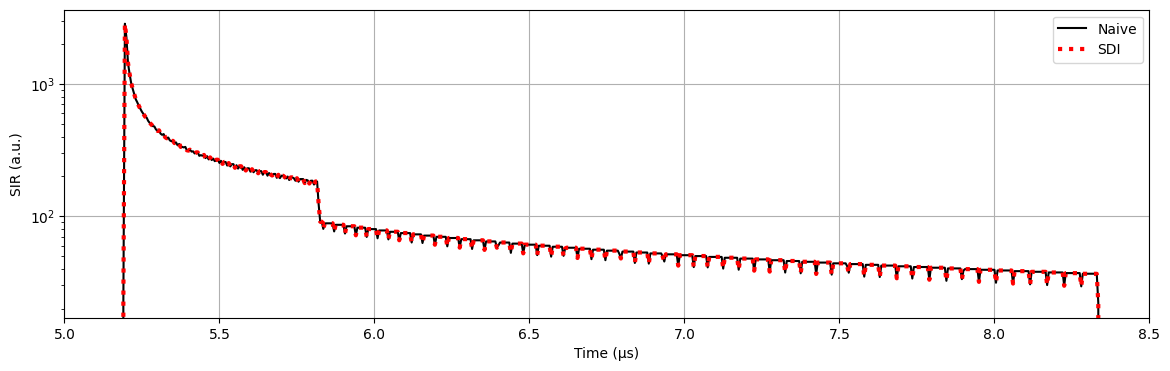

In [19]:

fig, ax = plt.subplots(figsize=(14, 4))
ax= plot_SIR_tx(time_grid, h1_naive, ax = ax, color = 'k',lw=1.5, label = 'Naive', linestyle = 'solid')
ax = plot_SIR_tx(time_grid, h1_sdi, ax = ax, color = 'red',lw=3, label = 'SDI', linestyle = 'dotted')
ax.set_xlim([5,8.5])
ax.set_yscale('log')
ax.legend()

Let's make an all in one graph

In [20]:
# Create elements
def plot_transducer_elements_plane(centers, element_width_mm, element_height_mm, *,cmap = 'jet', ax = None, title = None):

    colors = plt.get_cmap(cmap)(np.linspace(0, 1, centers.shape[0]))
    flag_return_ax = True
    if ax is None:
        flag_return_ax = False
        fig, ax = plt.subplots(figsize=(10, 2))

    n_elements = centers.shape[0]
    for i in range(n_elements):
        x_left = centers[i, 0]*1e3 - element_width_mm/2
        x_right = centers[i, 0]*1e3 + element_width_mm/2
        y_up = centers[i, 1]*1e3 + element_height_mm/2
        y_down = centers[i, 1]*1e3 - element_height_mm/2
        x_elem = [x_left, x_right, x_right, x_left, x_left]
        y_elem = [y_down, y_down, y_up, y_up, y_down]
        ax.fill(x_elem, y_elem, alpha=0.7, color=colors[i])
        ax.plot(x_elem, y_elem, color='black', lw=0.5)

    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_title(title, loc='left')
    ax.axis('equal')
    ax.grid()

    if flag_return_ax:
        return ax
    

# make a function to plot the transducers delays and apodization
def plot_delays_colored_with_apodization(delays, apodization, *, ax=None, title=None, add_cbar = True):
    if title is None:
        title = f'Transducer delays and apodization'
    flag_return_ax = True
    if ax is None:
        flag_return_ax = False
        fig, ax = plt.subplots(figsize=(10, 4))

    n_elements = delays.shape[0]
    cmap = plt.get_cmap('cool')
    norm = plt.Normalize(vmin=0, vmax=1)
    colors = cmap(norm(apodization))

    # Scatter plot with color-coded apodization
    ax.plot(range(n_elements), delays*1e6, 'k-', zorder = 1)
    sc = ax.scatter(range(n_elements), delays*1e6, c=apodization, cmap=cmap, norm=norm, s=40, label='Delay')
    ax.set_xlabel('Element Index')
    ax.set_ylabel('Delay (µs)')
    ax.set_title(title, loc='left')  # --- IGNORE ---
    ax.grid()

    # Add colorbar as legend for apodization
    if add_cbar:
        cax = inset_axes(ax, width="40%", height="8%", loc='lower right', borderpad=2)
        cbar = plt.colorbar(sc, cax=cax, orientation='horizontal')
        cbar.set_label('Apodization')
        cbar.set_ticks([0, 0.5, 1])
        cbar.set_ticklabels(['0', '0.5', '1'])

        # Move the label above the colorbar
        cbar.ax.xaxis.set_label_position('top')
        cbar.ax.xaxis.set_ticks_position('bottom')
    if flag_return_ax:
        return ax

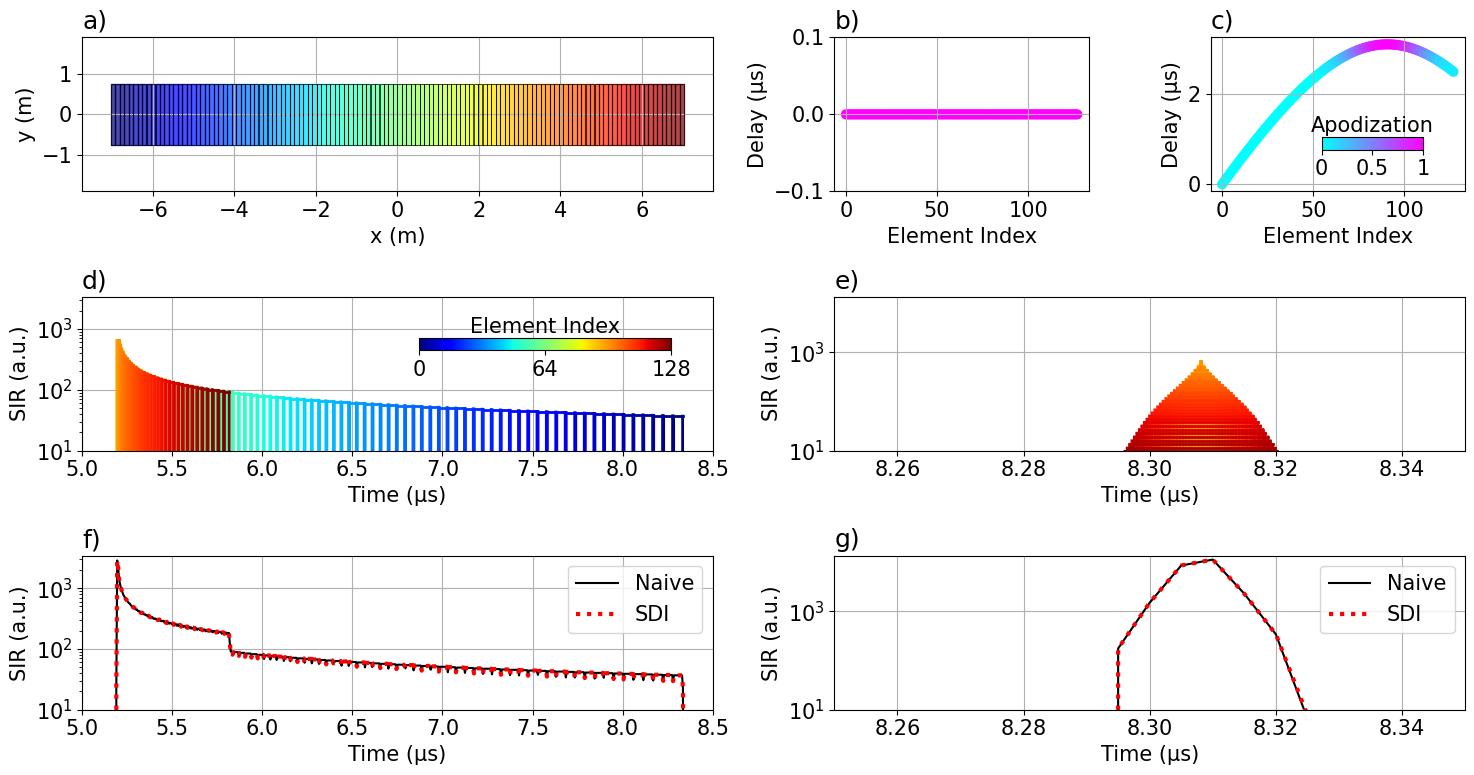

In [21]:
# Use matplotlib.gridspec to span plots across multiple columns
import matplotlib.gridspec as gridspec

# plt.style.use("seaborn-v0_8")
plt.rcParams.update({"font.size": 15})
plt.rcParams["font.weight"] = "normal"

fig = plt.figure(figsize=(15, 8))
gs = gridspec.GridSpec(3, 4, figure=fig)

# a) Transducer elements plane (span 2 columns)
ax_a = fig.add_subplot(gs[0, 0:2])
plot_transducer_elements_plane(centers, element_width_mm, element_height_mm, ax=ax_a, title='a)')

# b) Delays/apodization (no focus)
ax_b = fig.add_subplot(gs[0, 2])
plot_delays_colored_with_apodization(delay_zeros, apod_zeros, ax=ax_b, title='b)', add_cbar = False)
ax_b.set_ylim([-0.1, 0.1])

# c) Delays/apodization (focus)
ax_c = fig.add_subplot(gs[0, 3])
plot_delays_colored_with_apodization(delay_focus, apod_focus, ax=ax_c, title='c)')

# d) SIR events (no apod/delay), span 2 columns
ax_d = fig.add_subplot(gs[1, 0:2])
plot_SIR_events(events_wo_apod_delays, sub_y, ax=ax_d, title='d)', cmap=cmap)
ax_d.set_xlim([5, 8.5])
ax_d.set_yscale('log')
ax_d.set_ylim([10, h1_sdi.max()*1.2])
ax_d.grid('minor')

# e) SIR events (with apod/delay), span 2 columns
ax_e = fig.add_subplot(gs[1, 2:4])
plot_SIR_events(events_w_apod_delays, sub_y, ax=ax_e, title='e)', cmap=cmap, add_cbar= False)
ax_e.set_xlim([8.25, 8.35])
ax_e.set_yscale('log')
ax_e.set_ylim([10, h2_sdi.max()*1.2])
ax_e.grid('minor')

# f) SIR tx (no apod/delay), span 2 columns
ax_f = fig.add_subplot(gs[2, 0:2])
plot_SIR_tx(time_grid, h1_naive, ax=ax_f, color='k', lw=1.5, label='Naive', linestyle='solid')
plot_SIR_tx(time_grid, h1_sdi, ax=ax_f, color='red', lw=3, label='SDI', linestyle='dotted', title='f)')
ax_f.set_xlim([5, 8.5])
ax_f.set_yscale('log')
ax_f.set_ylim([10, h1_sdi.max()*1.2])
ax_f.legend()

# g) SIR tx (with apod/delay), span 2 columns
ax_g = fig.add_subplot(gs[2, 2:4])
plot_SIR_tx(time_grid, h2_naive, ax=ax_g, color='k', lw=1.5, label='Naive', linestyle='solid')
plot_SIR_tx(time_grid, h2_sdi, ax=ax_g, color='red', lw=3, label='SDI', linestyle='dotted', title='g)')
ax_g.set_xlim([8.25, 8.35])
ax_g.set_yscale('log')
ax_g.set_ylim([10, h2_sdi.max()*1.2])
ax_g.legend()

plt.tight_layout()

## 2.5. Theoretical performance

In the Naive approach, each patch $m$ is evaluated by filling the trapezoid over all its nonzero time samples. If we suppose that on average a trapezoid spans a fraction of the total temporal grid, corresponding to $\overline{\Delta k}$ samples, then, for $P$ field points, the computation time (CT) is on the order of

$$
CT(\text{Naive}) \sim O(P \cdot M \cdot \overline{\Delta k}) \tag{29}
$$

For clarity, consider the case of a single field point ($P=1$):

$$
CT(\text{Naive}_{(P=1)}) \sim O(M \cdot \overline{\Delta k}) \tag{30}
$$

In contrast, the SDI formulation (see Eq. [24]) avoids filling entire trapezoids. Instead, each patch contributes exactly eight Dirac deltas, requiring

$$
CT\left(\sum_{m}^{M} \Delta\delta(t-\tau_e)\right) \sim O(8M)
$$

at the expense of adding the cost of the two integrations over time each with $\sim O(T)$. Hence,

$$
CT(\text{SDI}_{(P=1)}) \sim O(8M + 2T) \tag{31}
$$

In general, the naive algorithm is faster only if

$$
M \cdot \overline{\Delta k} \ll 8M + 2T \tag{32}
$$

Which leads to

$$
\overline{\Delta k} \ll 8 + \frac{2T}{M} \tag{33}
$$

Let’s see how this look like for our example.

In [22]:

plt.rcParams.update({"font.size": 10})

def make_analysis_method(T, M, P, range_k_matrix):
    
    # When calling the Naive method, the range_k and T_M attributes are computed
    # and can be accessed after the first call to the object.
    kmean = np.mean(range_k_matrix)
    print(f"Mean of range_k : {kmean:.2f} for with P : {P}, T : {T}, M : {M}")
    condition_complete = 8 + 2*T/M
    print(f"Condition for complete trapezoids: {condition_complete:.2f}")

    fig, ax = plt.subplots(1,2,figsize=(10, 4))

    im = ax[0].imshow(range_k_matrix, aspect='auto', cmap = 'inferno')
    ax[0].set_title(r'a) $\Delta k$ ')
    ax[0].set_xlabel('Patch index')
    ax[0].set_ylabel('Point index')
    fig.colorbar(im, ax=ax[0])

    # plot Histogram of the krange

    ax[1].hist(range_k_matrix.flatten(), bins=10, color="#E91414", edgecolor="white", alpha=0.85)
    ax[1].set_xlabel(r'$\Delta k$ values')
    ax[1].set_ylabel('Events')
    ax[1].set_title(r'b) Distribution of $\Delta k$')
    ax[1].grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()

    return fig

Mean of range_k : 8.80 for with P : 1, T : 2048, M : 128
Condition for complete trapezoids: 40.00
Mean of range_k : 8.82 for with P : 1, T : 2048, M : 128
Condition for complete trapezoids: 40.00


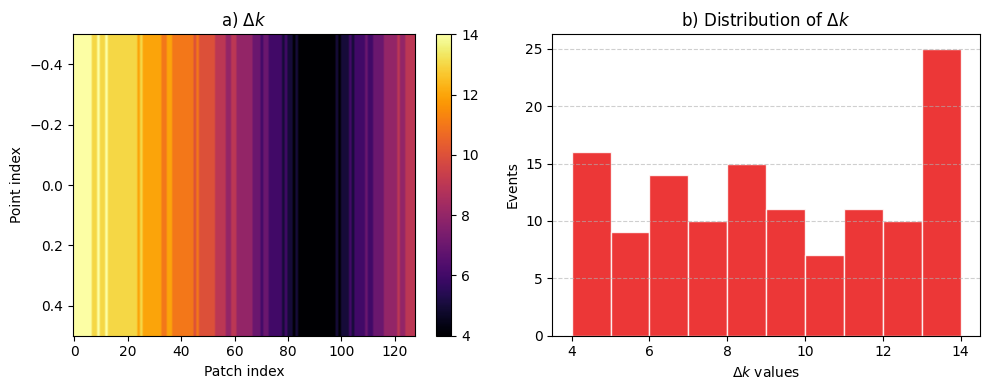

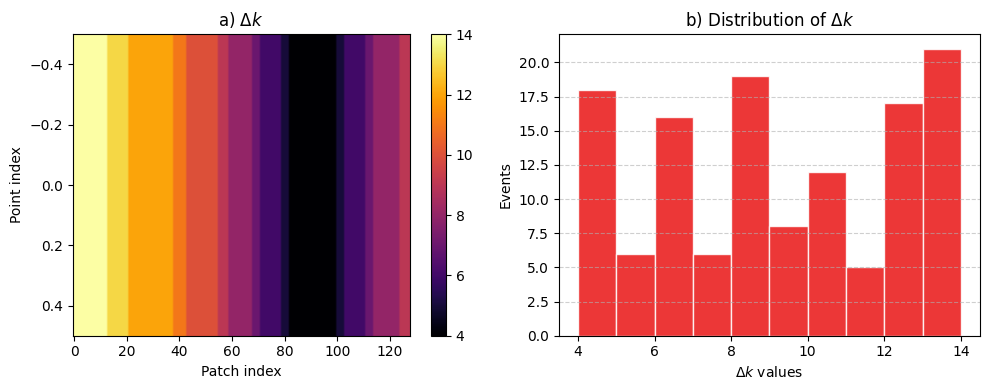

In [23]:
fig1 = make_analysis_method(T, M, P, range1_k_matrix)
fig2 = make_analysis_method(T, M, P, range2_k_matrix)

As we can see, for this example the `range_k`$=\overline{\Delta k}= 15.83$, and $ 8 + 2*T/M = 40.00$. Since they are both of the same order, we expect more or less the same performance on the methods. 

# 3. PyField

A better version of the methods where implemented in the class PyField. The code in PyField is made to be parallelized in CPU and avoid overhead on methods codes, so a fair comparison could be made.

## 3.1. Linear transducer array

## 3.1.1. Definition of transducer object

In [24]:
import pysonogen
from pysonogen.transducers import Domino, Zeus_Matrix
from PyField import PyField

focus_mm = np.array([0, 0, 8])
FoverD = 1

LinearArrayTransducer initialized in 0.0158 seconds.


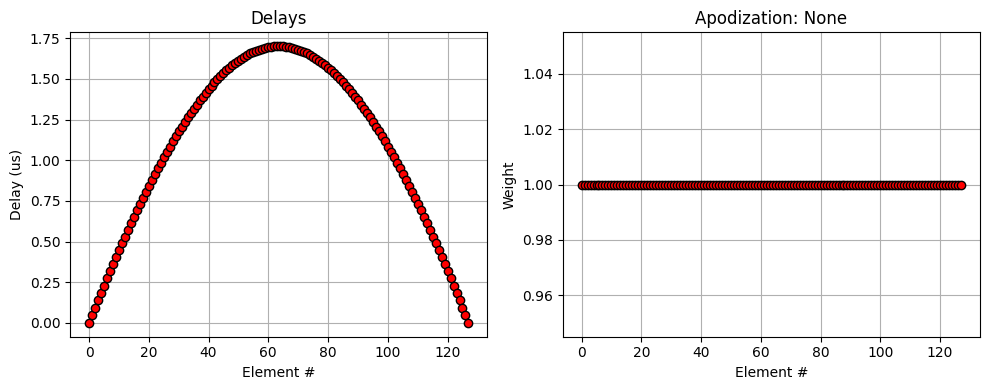

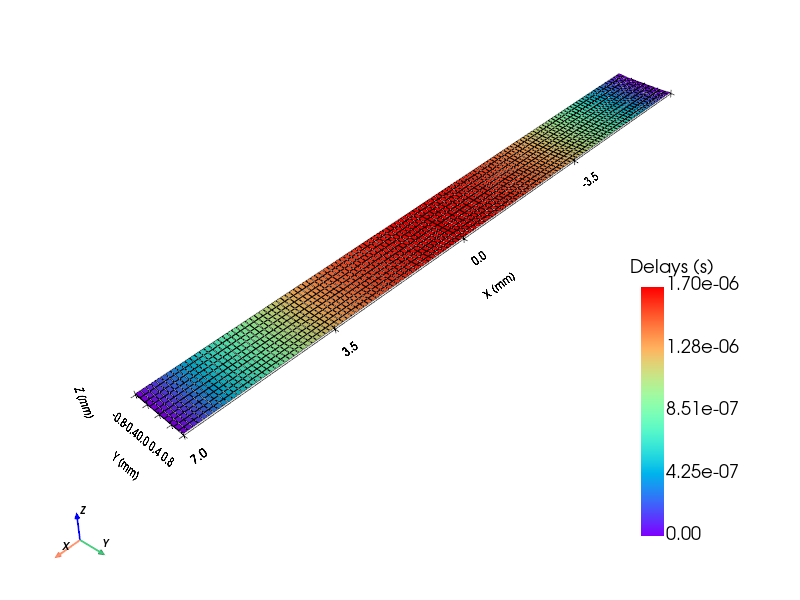

In [25]:
linear_array_probe = Domino()

delays = linear_array_probe.compute_delays(focus_mm=focus_mm)
# apodization = linear_array_probe.compute_apodization( 
#     focus_mm=focus_mm, FoverD=1)
linear_array_probe.plot_delays_apodization()
linear_array_probe.show(notebook=True, jupyter_backend='static', scalars = 'Delays')



## 3.1.2. Compute pressure field

In [26]:
x_half_size_mm = 0.25
y_half_size_mm = 0.5
z_half_size_mm = 1
x_extent_mm = [-x_half_size_mm+focus_mm[0], x_half_size_mm+focus_mm[0]]
y_extent_mm = [-y_half_size_mm+focus_mm[1], y_half_size_mm+focus_mm[1]]
z_extent_mm = [-z_half_size_mm +focus_mm[2], z_half_size_mm+focus_mm[2]]
dx_mm = 0.01
dy_mm = 0.02
dz_mm = 0.04

x = np.linspace(x_extent_mm[0], x_extent_mm[1], int((x_extent_mm[1]-x_extent_mm[0])/dx_mm)+1)
y = np.linspace(y_extent_mm[0], y_extent_mm[1], int((y_extent_mm[1]-y_extent_mm[0])/dy_mm)+1)
z = np.linspace(z_extent_mm[0], z_extent_mm[1], int((z_extent_mm[1]-z_extent_mm[0])/dz_mm)+1)
field_point_mm = np.array(np.meshgrid(x, y, z)).T.reshape(-1, 3)
print(f"Number of field points: {field_point_mm.shape[0]}, and x.shape: {x.shape}, y.shape: {y.shape}, z.shape: {z.shape}")
print(f"Field points from {field_point_mm.min(axis=0)} mm to {field_point_mm.max(axis=0)} mm")

Number of field points: 132651, and x.shape: (51,), y.shape: (51,), z.shape: (51,)
Field points from [-0.25 -0.5   7.  ] mm to [0.25 0.5  9.  ] mm


In [27]:
# The first call to the PyField object will take some time to prepare 
# the parallel computation and compile the numba kernels,
# but subsequent calls will be much faster.
linear_field = PyField(linear_array_probe)
x0, y0, z0, p_linearfield0 = linear_field(field_point_mm, method = 'naive')

Computing SIR for 132651 points and 1280 patches...
Computed time grid from 4.44 us to 9.31 us, with 973 samples in 0.03 seconds.
Transducer SIR computed in 4.66 seconds...
Pressure computed from SIR in 0.81 seconds...
Pressure field computed in 7.16 seconds...


In [28]:
x1, y1, z1, p_linearfield1 = linear_field(field_point_mm, method = 'naive')

Computing SIR for 132651 points and 1280 patches...
Computed time grid from 4.44 us to 9.31 us, with 973 samples in 0.05 seconds.
Transducer SIR computed in 0.56 seconds...
Pressure computed from SIR in 0.84 seconds...
Pressure field computed in 1.82 seconds...


In [29]:
x2, y2, z2, p_linearfield2 = linear_field(field_point_mm, method = 'sdi')

Computing SIR for 132651 points and 1280 patches...
Computed time grid from 4.44 us to 9.31 us, with 973 samples in 0.04 seconds.
Transducer SIR computed in 0.44 seconds...
Pressure computed from SIR in 0.82 seconds...
Pressure field computed in 1.67 seconds...


Taking slice (0.0,0.0,8.0) => x_ind, y_ind, z_ind = 26/51, 26/51, 26/51


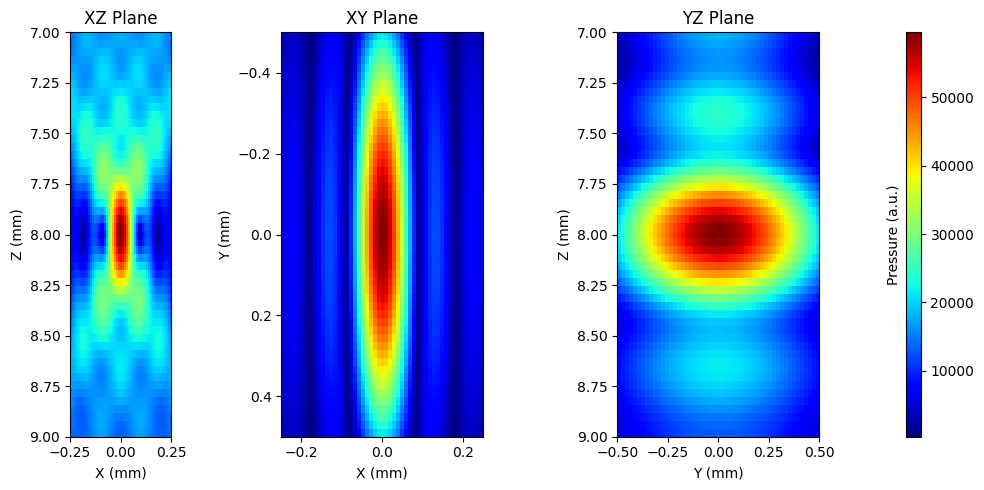

Taking slice (0.0,0.0,8.0) => x_ind, y_ind, z_ind = 26/51, 26/51, 26/51


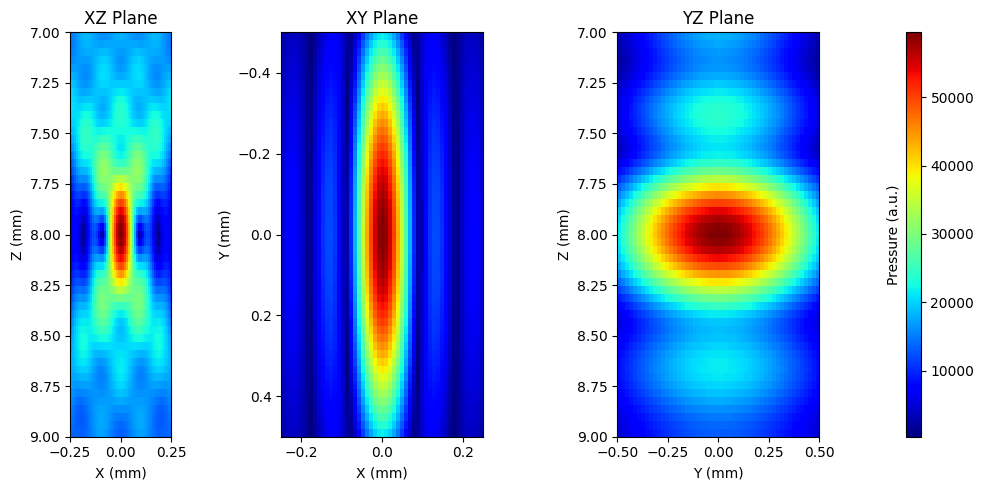

In [30]:
pysonogen.plot_field_planes(p_linearfield1, x1, y1, z1)
pysonogen.plot_field_planes(p_linearfield2, x2, y2, z2)

Computing SIR for 132651 points and 1280 patches...
Computed time grid from 4.44 us to 9.31 us, with 973 samples in 0.04 seconds.
Transducer SIR computed in 4.26 seconds...
Pressure computed from SIR in 0.82 seconds...
Pressure field computed in 5.49 seconds...
Taking slice (0.0,0.0,8.0) => x_ind, y_ind, z_ind = 26/51, 26/51, 26/51


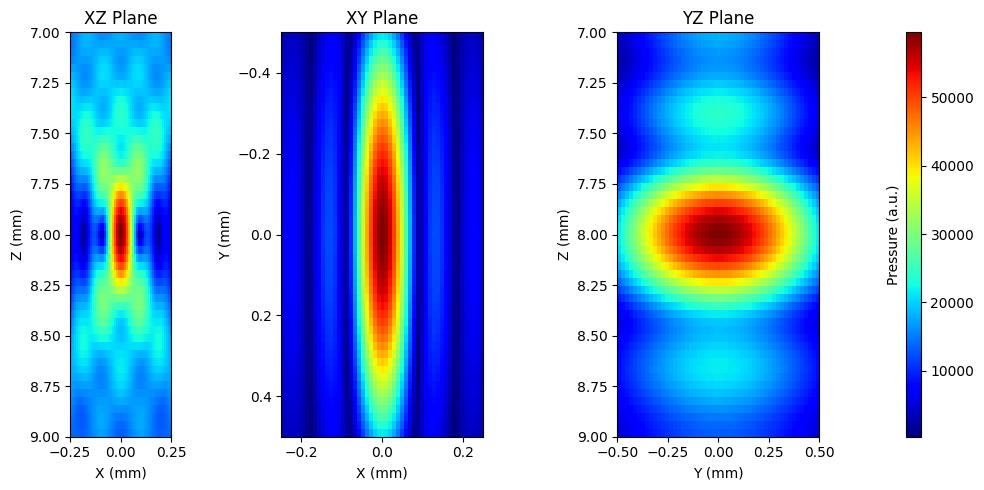

In [31]:
x3, y3, z3, p_linearfield3 = linear_field(field_point_mm, method = 'auto')
pysonogen.plot_field_planes(p_linearfield3, x3, y3, z3)

## 3.2. Matrix transducer

### 3.2.1. Definition of transducer object

MatrixArrayTransducer initialized with 3025 elements and 12100 patches.
Transducer initialized in 0.0606 seconds.


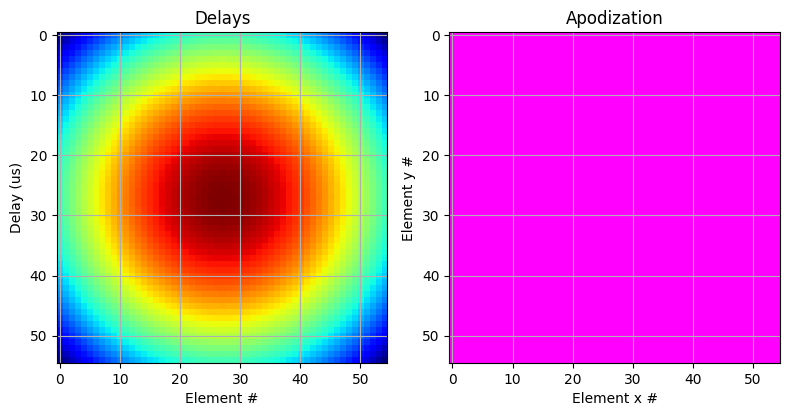

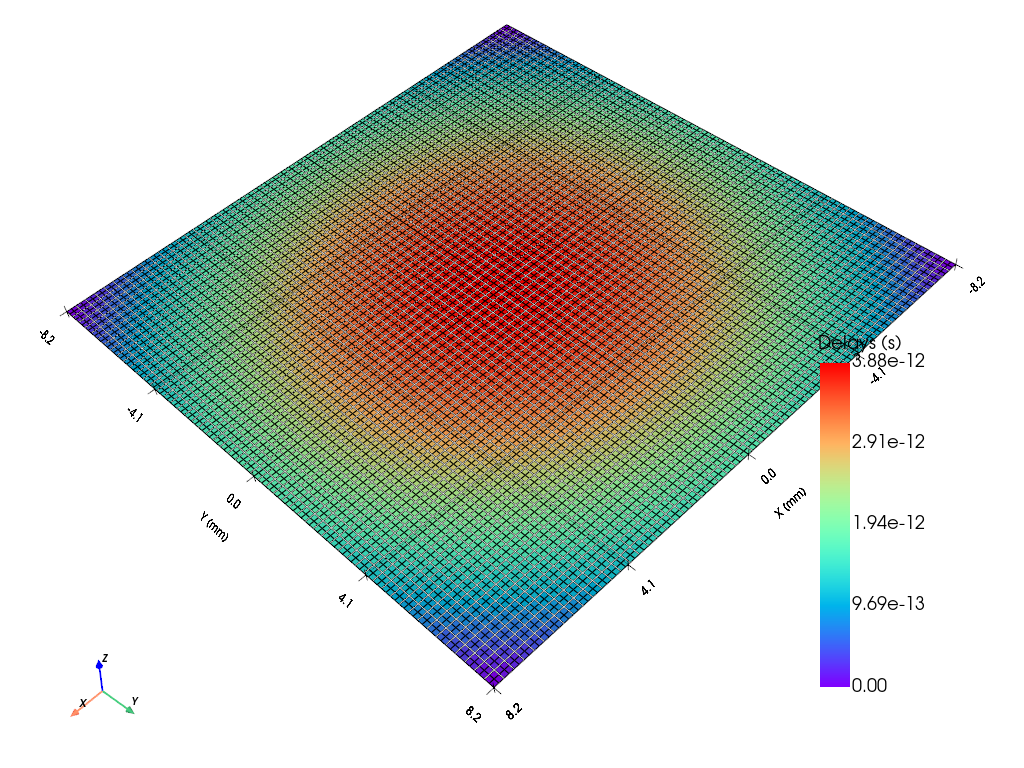

In [32]:
matrix_array_probe = Zeus_Matrix()

delays = matrix_array_probe.compute_delays(focus_mm=focus_mm)
# apodization = matrix_array_probe.compute_apodization( 
#     focus_mm=focus_mm, FoverD=FoverD)
matrix_array_probe.plot_delays_apodization()
matrix_array_probe.show(notebook=True, jupyter_backend='static', scalars = "Delays")


### 3.2.2. Compute pressure field

In [33]:
x_half_size_mm = 0.25
y_half_size_mm = 0.5
z_half_size_mm = 1
x_extent_mm = [-x_half_size_mm+focus_mm[0], x_half_size_mm+focus_mm[0]]
y_extent_mm = [-y_half_size_mm+focus_mm[1], y_half_size_mm+focus_mm[1]]
z_extent_mm = [-z_half_size_mm +focus_mm[2], z_half_size_mm+focus_mm[2]]
dx_mm = 0.01
dy_mm = 0.02
dz_mm = 0.04

# x_extent_mm = [-x_half_size_mm+focus_mm[0], x_half_size_mm+focus_mm[0]]
# y_extent_mm = [-y_half_size_mm+focus_mm[1], y_half_size_mm+focus_mm[1]]
# z_extent_mm = [-z_half_size_mm +focus_mm[2], z_half_size_mm+focus_mm[2]]
# dx_mm = 0.03
# dy_mm = 0.03
# dz_mm = 0.05

x = np.linspace(x_extent_mm[0], x_extent_mm[1], int((x_extent_mm[1]-x_extent_mm[0])/dx_mm)+1)
y = np.linspace(y_extent_mm[0], y_extent_mm[1], int((y_extent_mm[1]-y_extent_mm[0])/dy_mm)+1)
z = np.linspace(z_extent_mm[0], z_extent_mm[1], int((z_extent_mm[1]-z_extent_mm[0])/dz_mm)+1)
field_info_mm = np.array(np.meshgrid(x, y, z)).T.reshape(-1, 3)
print(f"Number of field points: {field_info_mm.shape[0]}, x.shape: {x.shape}, y.shape: {y.shape}, z.shape: {z.shape}")
print(f"Field points from {field_info_mm.min(axis=0)} mm to {field_info_mm.max(axis=0)} mm")

Number of field points: 132651, x.shape: (51,), y.shape: (51,), z.shape: (51,)
Field points from [-0.25 -0.5   7.  ] mm to [0.25 0.5  9.  ] mm


In [34]:
matrix_field = PyField(matrix_array_probe)
x1, y1, z1, p_matrixfield1 = matrix_field(field_info_mm, method = 'naive')

Computing SIR for 132651 points and 12100 patches...
Computed time grid from 4.45 us to 13.76 us, with 1862 samples in 0.35 seconds.
Transducer SIR computed in 6.85 seconds...
Pressure computed from SIR in 1.15 seconds...
Pressure field computed in 11.91 seconds...


In [35]:
x1, y1, z1, p_matrixfield1 = matrix_field(field_info_mm, method = 'naive')

Computing SIR for 132651 points and 12100 patches...
Computed time grid from 4.45 us to 13.76 us, with 1862 samples in 0.36 seconds.
Transducer SIR computed in 7.02 seconds...
Pressure computed from SIR in 0.95 seconds...
Pressure field computed in 12.12 seconds...


In [36]:
x2, y2, z2, p_matrixfield2 = matrix_field(field_info_mm, method = 'sdi')

Computing SIR for 132651 points and 12100 patches...
Computed time grid from 4.45 us to 13.76 us, with 1862 samples in 0.60 seconds.
Transducer SIR computed in 3.61 seconds...
Pressure computed from SIR in 1.19 seconds...
Pressure field computed in 9.17 seconds...


Taking slice (0.0,0.0,8.0) => x_ind, y_ind, z_ind = 26/51, 26/51, 26/51


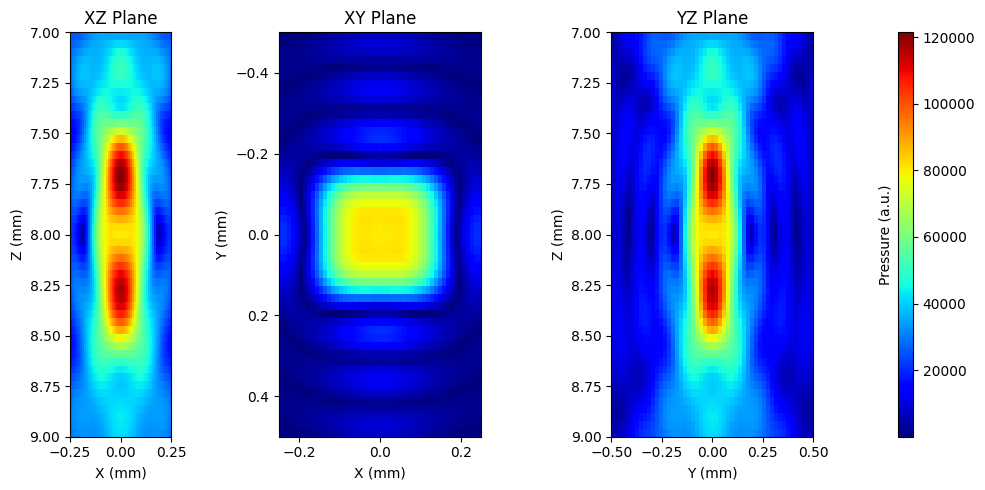

Taking slice (0.0,0.0,8.0) => x_ind, y_ind, z_ind = 26/51, 26/51, 26/51


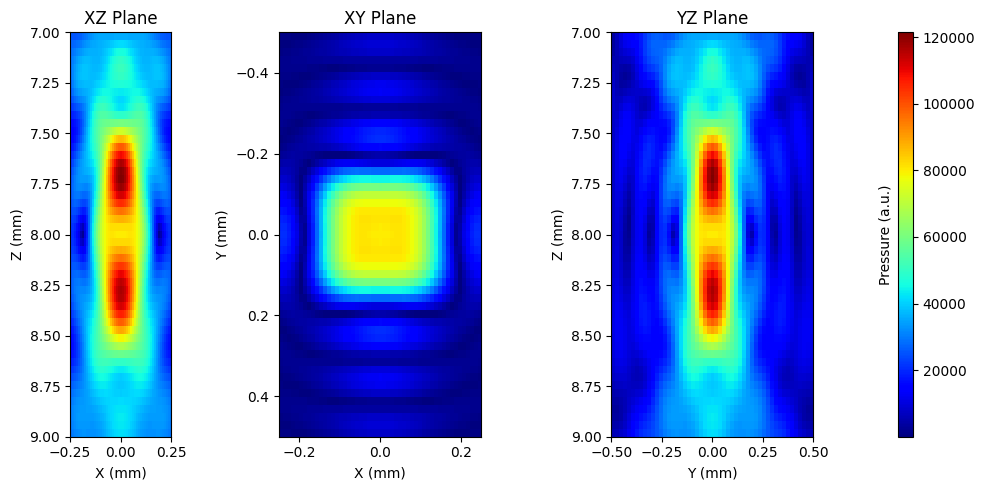

In [37]:
pysonogen.plot_field_planes(p_matrixfield1, x1, y1, z1)
pysonogen.plot_field_planes(p_matrixfield2, x2, y2, z2)

Computing SIR for 132651 points and 12100 patches...
Computed time grid from 4.45 us to 13.76 us, with 1862 samples in 0.36 seconds.
Transducer SIR computed in 3.58 seconds...
Pressure computed from SIR in 1.01 seconds...
Pressure field computed in 8.89 seconds...
Taking slice (0.0,0.0,8.0) => x_ind, y_ind, z_ind = 26/51, 26/51, 26/51


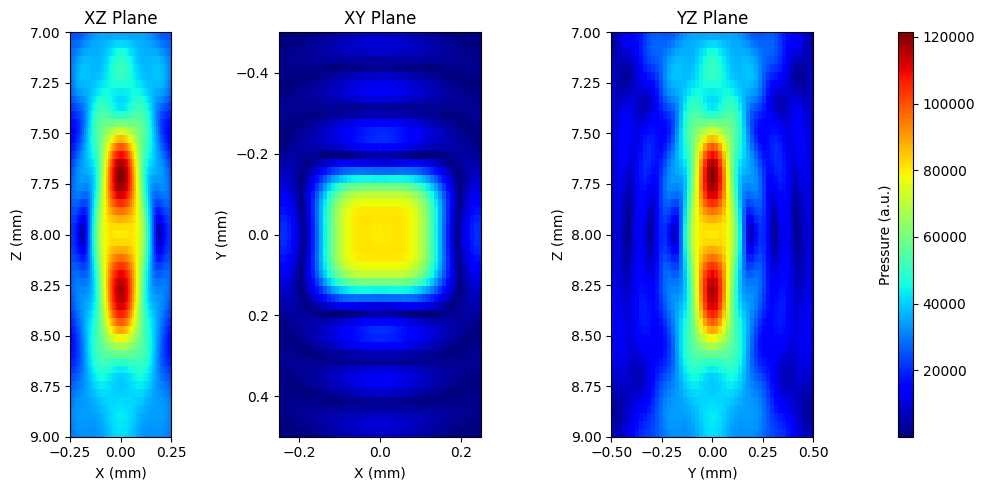

In [38]:
x3, y3, z3, p_matrixfield3 = matrix_field(field_info_mm, method = 'auto')
pysonogen.plot_field_planes(p_matrixfield3, x3, y3, z3)

# 4. Model comparison

## 4.1. Pressure Field

Let's examine the difference between both results

### 4.1.1. Linear array

max_values Naive and SDI: 59526.0234375, 59506.07421875
Max difference between SDI and naive method at index (np.int64(21), np.int64(25), np.int64(25)), value: 44.4921875, relative: 0.10 %
Min difference between SDI and naive method at index (np.int64(26), np.int64(25), np.int64(28)), value: -44.5625, relative: -0.08 %
Point of max difference at [-0.04  0.    8.  ] mm
Point of min difference at [0.01 0.   8.12] mm
Taking slice (0.0,0.0,8.0) => x_ind, y_ind, z_ind = 26/51, 26/51, 26/51


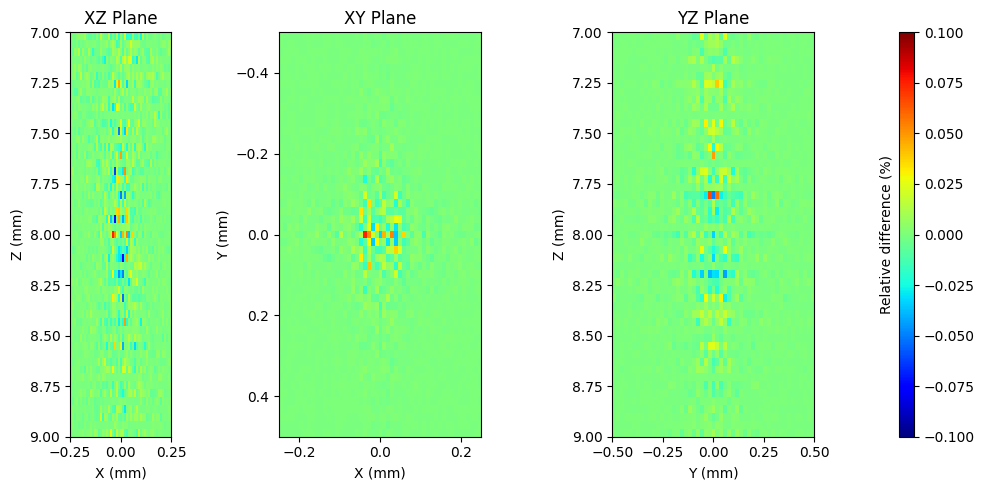

Taking slice (0.0,0.0,8.0) => x_ind, y_ind, z_ind = 26/51, 26/51, 26/51


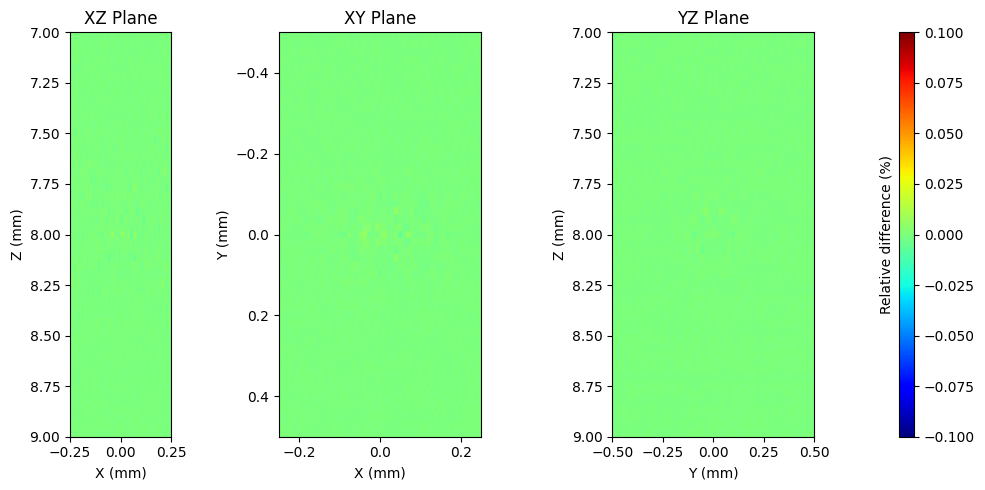

In [68]:
diff_linear_field = p_linearfield2 - p_linearfield1
diff_linear_auto_field = p_linearfield3 - p_linearfield1

print(f"max_values Naive and SDI: {p_linearfield1.max()}, {p_linearfield2.max()}")

max_idx = np.unravel_index(np.argmax(diff_linear_field), diff_linear_field.shape)
min_idx = np.unravel_index(np.argmin(diff_linear_field), diff_linear_field.shape)
print(f"Max difference between SDI and naive method at index {max_idx}, value: {diff_linear_field[max_idx]}, relative: {diff_linear_field[max_idx]/p_linearfield1[max_idx]*100:.2f} %") 
print(f"Min difference between SDI and naive method at index {min_idx}, value: {diff_linear_field[min_idx]}, relative: {diff_linear_field[min_idx]/p_linearfield1[min_idx]*100:.2f} %")

point_max_diff = np.array([x1[max_idx[0]], y1[max_idx[1]], z1[max_idx[2]]])
point_min_diff = np.array([x1[min_idx[0]], y1[min_idx[1]], z1[min_idx[2]]])
print(f"Point of max difference at {point_max_diff} mm")
print(f"Point of min difference at {point_min_diff} mm")

pysonogen.plot_field_planes(diff_linear_field/p_linearfield1.max()*100, x2, y2, z2, vmin = -0.1, vmax = 0.1, label = 'Relative difference (%)')
pysonogen.plot_field_planes(diff_linear_auto_field/p_linearfield1.max()*100, x3, y3, z3, vmin = -0.1, vmax = 0.1, label = 'Relative difference (%)')

In [40]:
_, h_naive_max = linear_field.compute_sir(point_max_diff*1e-3, method = 'naive')
_, h_sdi_max = linear_field.compute_sir(point_max_diff*1e-3, method = 'sdi')
_, h_auto_max = linear_field.compute_sir(point_max_diff*1e-3, method = 'auto')

_, h_naive_min = linear_field.compute_sir(point_min_diff*1e-3, method = 'naive')
_, h_sdi_min = linear_field.compute_sir(point_min_diff*1e-3, method = 'sdi')
_, h_auto_min = linear_field.compute_sir(point_min_diff*1e-3, method = 'auto')


Computing SIR for 1 points and 1280 patches...
Computed time grid from 5.11 us to 8.70 us, with 718 samples in 0.00 seconds.
Transducer SIR computed in 0.02 seconds...
Computing SIR for 1 points and 1280 patches...
Computed time grid from 5.11 us to 8.70 us, with 718 samples in 0.00 seconds.
Transducer SIR computed in 0.00 seconds...
Computing SIR for 1 points and 1280 patches...
Computed time grid from 5.11 us to 8.70 us, with 718 samples in 0.00 seconds.
Transducer SIR computed in 0.00 seconds...
Computing SIR for 1 points and 1280 patches...
Computed time grid from 5.19 us to 8.74 us, with 712 samples in 0.00 seconds.
Transducer SIR computed in 0.00 seconds...
Computing SIR for 1 points and 1280 patches...
Computed time grid from 5.19 us to 8.74 us, with 712 samples in 0.00 seconds.
Transducer SIR computed in 0.00 seconds...
Computing SIR for 1 points and 1280 patches...
Computed time grid from 5.19 us to 8.74 us, with 712 samples in 0.00 seconds.
Transducer SIR computed in 0.00 sec

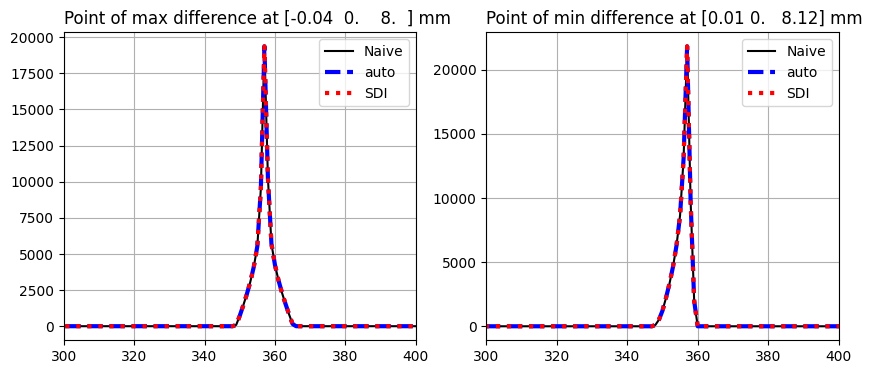

In [66]:
fig, ax = plt.subplots(1,2,figsize=(10, 4))
ax = ax.flatten()
k = 0
ax[k].plot(h_naive_max, color = 'k', lw=1.5, label = 'Naive', linestyle = 'solid')
ax[k].plot(h_auto_max, color = 'blue', lw=3, label = 'auto', linestyle = 'dashed')
ax[k].plot(h_sdi_max, color = 'red', lw=3, label = 'SDI', linestyle = 'dotted')
ax[k].set_xlim([300, 400])
ax[k].set_title(f'Point of max difference at {point_max_diff} mm', loc='left')
ax[k].grid('minor')
ax[k].legend()
k += 1
ax[k].plot(h_naive_min, color = 'k', lw=1.5, label = 'Naive', linestyle = 'solid')
ax[k].plot(h_auto_min, color = 'blue', lw=3, label = 'auto', linestyle = 'dashed')
ax[k].plot(h_sdi_min, color = 'red', lw=3, label = 'SDI', linestyle = 'dotted')
ax[k].set_xlim([300, 400])
ax[k].set_title(f'Point of min difference at {point_min_diff} mm', loc='left')
ax[k].grid('minor')
ax[k].legend()



### 4.1.2. Matrix array

max_values Naive and SDI: 121405.640625, 121406.59375
Max difference between SDI and naive method at index (np.int64(25), np.int64(25), np.int64(25)), value: 55.65625, relative: 0.07 %
Min difference between SDI and naive method at index (np.int64(24), np.int64(26), np.int64(23)), value: -49.0234375, relative: -0.06 %
Point of max difference at [0. 0. 8.] mm
Point of min difference at [-0.01  0.02  7.92] mm
Taking slice (0.0,0.0,8.0) => x_ind, y_ind, z_ind = 26/51, 26/51, 26/51


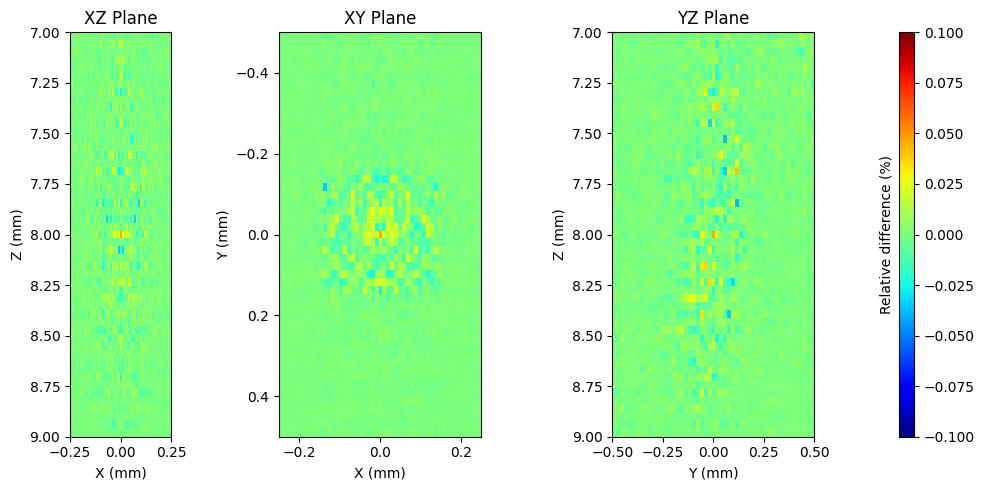

Taking slice (0.0,0.0,8.0) => x_ind, y_ind, z_ind = 26/51, 26/51, 26/51


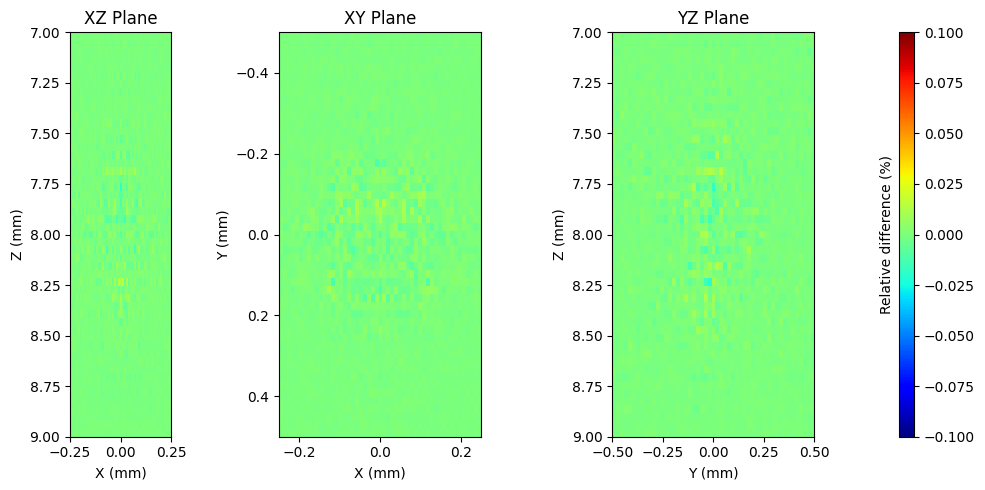

In [67]:
diff_matrix_field = p_matrixfield2 - p_matrixfield1
diff_matrix_auto_field = p_matrixfield3 - p_matrixfield1

print(f"max_values Naive and SDI: {p_matrixfield1.max()}, {p_matrixfield2.max()}")

max_idx_matrix = np.unravel_index(np.argmax(diff_matrix_field), diff_matrix_field.shape)
min_idx_matrix = np.unravel_index(np.argmin(diff_matrix_field), diff_matrix_field.shape)
print(f"Max difference between SDI and naive method at index {max_idx_matrix}, value: {diff_matrix_field[max_idx_matrix]}, relative: {diff_matrix_field[max_idx_matrix]/p_matrixfield1[max_idx_matrix]*100:.2f} %") 
print(f"Min difference between SDI and naive method at index {min_idx_matrix}, value: {diff_matrix_field[min_idx_matrix]}, relative: {diff_matrix_field[min_idx_matrix]/p_matrixfield1[min_idx_matrix]*100:.2f} %") 

point_max_diff_matrix = np.array([x1[max_idx_matrix[0]], y1[max_idx_matrix[1]], z1[max_idx_matrix[2]]])
point_min_diff_matrix = np.array([x1[min_idx_matrix[0]], y1[min_idx_matrix[1]], z1[min_idx_matrix[2]]])
print(f"Point of max difference at {point_max_diff_matrix} mm")
print(f"Point of min difference at {point_min_diff_matrix} mm")

pysonogen.plot_field_planes(diff_matrix_field/p_matrixfield1.max()*100, x2, y2, z2, vmin = -0.1, vmax = 0.1, label = 'Relative difference (%)')
pysonogen.plot_field_planes(diff_matrix_auto_field/p_matrixfield1.max()*100, x3, y3, z3, vmin = -0.1, vmax = 0.1, label = 'Relative difference (%)')

In [43]:
_, h_naive_max_matrix =  matrix_field.compute_sir(point_max_diff_matrix*1e-3, method = 'naive')
_, h_sdi_max_matrix = matrix_field.compute_sir(point_max_diff_matrix*1e-3, method = 'sdi')
_, h_auto_max_matrix = matrix_field.compute_sir(point_max_diff_matrix*1e-3, method = 'auto')

_, h_naive_min_matrix = matrix_field.compute_sir(point_min_diff_matrix*1e-3, method = 'naive')
_, h_sdi_min_matrix = matrix_field.compute_sir(point_min_diff_matrix*1e-3, method = 'sdi')
_, h_auto_min_matrix = matrix_field.compute_sir(point_min_diff_matrix*1e-3, method = 'auto')

Computing SIR for 1 points and 12100 patches...
Computed time grid from 5.10 us to 13.10 us, with 1600 samples in 0.00 seconds.
Transducer SIR computed in 0.18 seconds...
Computing SIR for 1 points and 12100 patches...
Computed time grid from 5.10 us to 13.10 us, with 1600 samples in 0.00 seconds.
Transducer SIR computed in 0.00 seconds...
Computing SIR for 1 points and 12100 patches...
Computed time grid from 5.10 us to 13.10 us, with 1600 samples in 0.00 seconds.
Transducer SIR computed in 0.00 seconds...
Computing SIR for 1 points and 12100 patches...
Computed time grid from 5.05 us to 13.08 us, with 1607 samples in 0.00 seconds.
Transducer SIR computed in 0.00 seconds...
Computing SIR for 1 points and 12100 patches...
Computed time grid from 5.05 us to 13.08 us, with 1607 samples in 0.00 seconds.
Transducer SIR computed in 0.00 seconds...
Computing SIR for 1 points and 12100 patches...
Computed time grid from 5.05 us to 13.08 us, with 1607 samples in 0.00 seconds.
Transducer SIR co

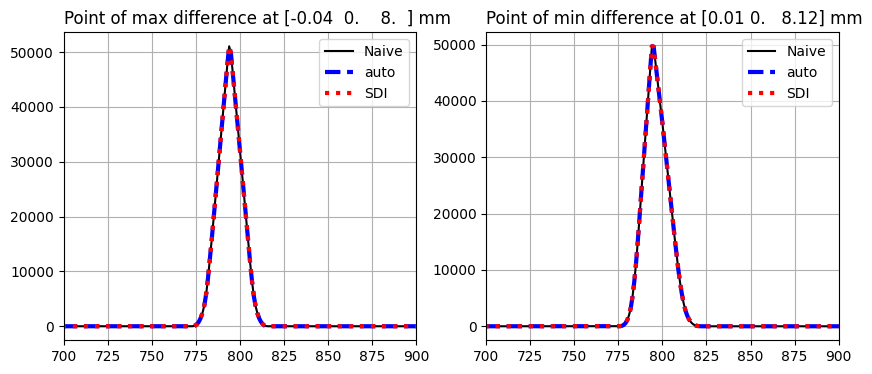

In [63]:
fig, ax = plt.subplots(1,2,figsize=(10, 4))
ax = ax.flatten()
k = 0
ax[k].plot(h_naive_max_matrix, color = 'k', lw=1.5, label = 'Naive', linestyle = 'solid')
ax[k].plot(h_auto_max_matrix, color = 'blue', lw=3, label = 'auto', linestyle = 'dashed')
ax[k].plot(h_sdi_max_matrix, color = 'red', lw=3, label = 'SDI', linestyle = 'dotted')
ax[k].set_xlim([700, 900])
ax[k].set_title(f'Point of max difference at {point_max_diff} mm', loc='left')
ax[k].grid('minor')
ax[k].legend()
k += 1
ax[k].plot(h_naive_min_matrix, color = 'k', lw=1.5, label = 'Naive', linestyle = 'solid')
ax[k].plot(h_auto_min_matrix, color = 'blue', lw=3, label = 'auto', linestyle = 'dashed')
ax[k].plot(h_sdi_min_matrix, color = 'red', lw=3, label = 'SDI', linestyle = 'dotted')
ax[k].set_xlim([700, 900])
ax[k].set_title(f'Point of min difference at {point_min_diff} mm', loc='left')
ax[k].grid('minor')
ax[k].legend()

## 4.2. Theoretical performance

In [45]:
range_k_linear = linear_field.range_k
range_k_matrix = matrix_field.range_k


Mean of range_k : 8.41 for with P : 1, T : 712, M : 1280
Condition for complete trapezoids: 9.11
Mean of range_k : 16.59 for with P : 1, T : 1607, M : 12100
Condition for complete trapezoids: 8.27


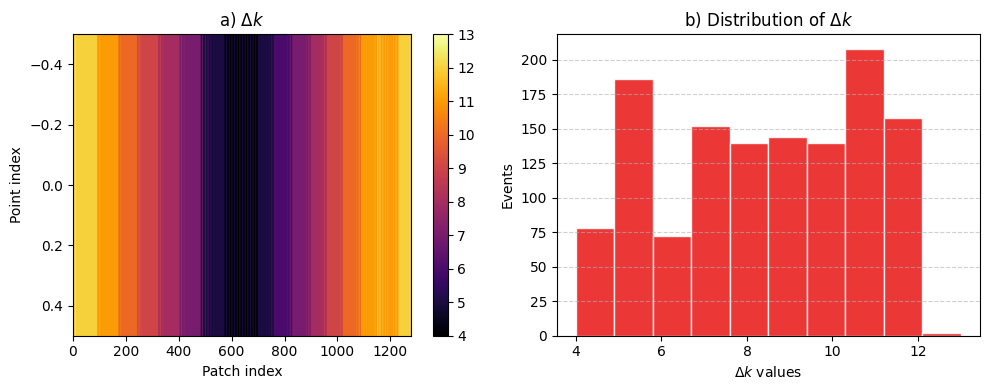

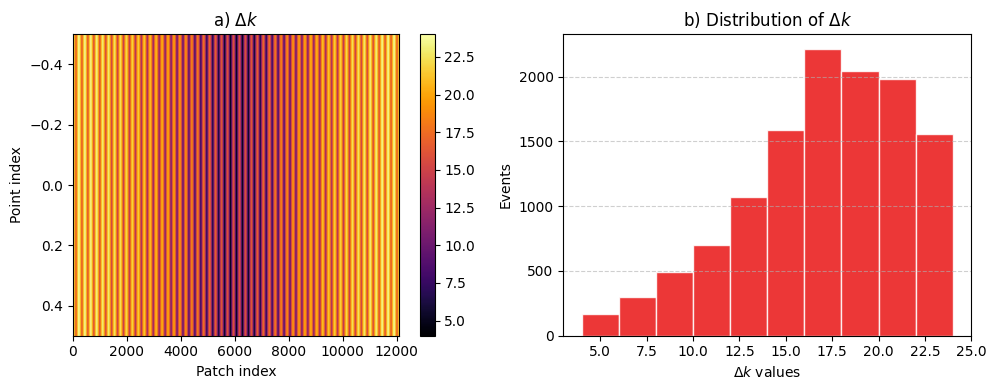

In [46]:
M_linear = linear_field.M
M_matrix = matrix_field.M

T_linear = linear_field.T_log[-1]
T_matrix = matrix_field.T_log[-1]

P_linear = linear_field.P_log[-1]
P_matrix = matrix_field.P_log[-1]

figlinear = make_analysis_method(T_linear, M_linear, P_linear, range_k_linear)
figmatrix = make_analysis_method(T_matrix, M_matrix, P_matrix, range_k_matrix)

# 5. Model validation

## 5.1 Validation with experimental data

A linear array probe with 128 elements with 110 $\mu m$ pitch, an elevation focus of 8 mm, and a center frequency of 15 MHz was calibrated using the Acertara Acoustic Measurement System (AMS). This system combines hardware and software for characterizing acoustic energy from diagnostic and therapeutic ultrasound devices, and includes a water treatment unit for degassing and filtration. A calibrated hydrophone (Onda HGL-0085, SN: 2852) with an integral preamplifier (AG-2010, SN: 1403) was mounted on a 3D motorized positioning system. The hydrophone output was recorded using a Tektronix MDO3012B oscilloscope.

The probe was driven by a Verasonics research ultrasound system to generate a focused sequence. To characterize the lateral and elevational field distribution, ten XY scans were acquired at depths of 4.5, 5.5, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 10.5, and 11.5 mm. To capture the axial pressure distribution, a Z-scan was performed along the central axis (x, y = 0, 0) from 4.5 to 11.5 mm with a step size of 0.01 mm, from which the peak intensity integral (PII) was extracted. By combining interpolation of the XY scans with the axial profile, a high-resolution 3D pressure field was reconstructed and later compared with simulation results.


### 5.1.1. Import experimental data

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import pysonogen
import pysonogen.transducers as transducers
from PyField import PyField


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
folder = 'Data_exp/'
name_exp_data = 'calibration_data_FD1_FD15_FD2.npz'
path_exp_data = folder + name_exp_data
Exp_data = np.load(path_exp_data, allow_pickle=True)
data = Exp_data['processed_data'].item()
print(data.keys())
depth_correction_mm = 0.5
real_x1, real_y1, real_z1, real_FD1 = data['x1'], data['y1'], data['z1'] - depth_correction_mm, data['FD1']
real_x15, real_y15, real_z15, real_FD15 = data['x15'], data['y15'], data['z15'] - depth_correction_mm, data['FD15']
real_x2, real_y2, real_z2, real_FD2 = data['x2'], data['y2'], data['z2'] - depth_correction_mm, data['FD2']

dict_keys(['FD1', 'x1', 'y1', 'z1', 'FD15', 'x15', 'y15', 'z15', 'FD2', 'x2', 'y2', 'z2'])


### 5.1.2. Perform simulations

In [49]:
focus_mm = np.array([0, 0, 8])
method = 'auto'

domino = transducers.Domino()
delays = domino.compute_delays(focus_mm=focus_mm)
 
field_points_FD1 = np.meshgrid(real_x1, real_y1, real_z1)
field_points_FD1 = np.array(field_points_FD1).T.reshape(-1, 3)

field_points_FD15 = np.meshgrid(real_x15, real_y15, real_z15)
field_points_FD15 = np.array(field_points_FD15).T.reshape(-1, 3)    

field_points_FD2 = np.meshgrid(real_x2, real_y2, real_z2)
field_points_FD2 = np.array(field_points_FD2).T.reshape(-1, 3)


LinearArrayTransducer initialized in 0.0158 seconds.


In [50]:
FoverD = 1
apodization = domino.compute_apodization( 
    focus_mm=focus_mm, FoverD=FoverD, apodization_type='rect')
# domino.plot_delays_apodization()

domino_field = PyField(domino)
simu_x1, simu_y1, simu_z1, pressure_FD1 = domino_field(field_points_FD1, method = method)


Computing SIR for 1820000 points and 1280 patches...
Computed time grid from 2.82 us to 10.65 us, with 1566 samples in 0.52 seconds.
Transducer SIR computed in 5.77 seconds...
Pressure computed from SIR in 12.05 seconds...
Pressure field computed in 23.60 seconds...


In [51]:
FoverD = 1.5
apodization = domino.compute_apodization( 
    focus_mm=focus_mm, FoverD=FoverD, apodization_type='rect')
# domino.plot_delays_apodization()

domino_field = PyField(domino)
simu_x15, simu_y15, simu_z15, pressure_FD15 = domino_field(field_points_FD15, method = method)

Computing SIR for 2184000 points and 1280 patches...
Computed time grid from 2.82 us to 10.65 us, with 1566 samples in 0.63 seconds.
Transducer SIR computed in 7.35 seconds...
Pressure computed from SIR in 14.61 seconds...
Pressure field computed in 29.03 seconds...


In [52]:
FoverD = 2
apodization = domino.compute_apodization( 
    focus_mm=focus_mm, FoverD=FoverD, apodization_type='rect')
# domino.plot_delays_apodization()

domino_field = PyField(domino)
simu_x2, simu_y2, simu_z2, pressure_FD2 = domino_field(field_points_FD2, method = method)

Computing SIR for 1820000 points and 1280 patches...
Computed time grid from 2.82 us to 10.65 us, with 1566 samples in 0.95 seconds.
Transducer SIR computed in 4.94 seconds...
Pressure computed from SIR in 12.01 seconds...
Pressure field computed in 23.39 seconds...


In [53]:
# Normalize
pressure_FD1 /= np.max(np.abs(pressure_FD1))
pressure_FD15 /= np.max(np.abs(pressure_FD15))
pressure_FD2 /= np.max(np.abs(pressure_FD2))

# Convert to PII
simu_FD1 = np.max(real_FD1)*pressure_FD1**2
simu_FD15 = np.max(real_FD15)*pressure_FD15**2
simu_FD2 = np.max(real_FD2)*pressure_FD2**2

### 5.1.3. 3D Visualization of pressure fields

In [54]:
import pysonogen.functions.plotting_pyvista as pv_plotting
import pyvista as pv

def set_custom_style(plotter):
    cube_actor =plotter.show_bounds(
            grid = 'back', color = 'black', font_size = 12,
            location = 'outer',
            n_xlabels =3 , n_ylabels=5, n_zlabels=13-5,
            xtitle = "X (mm)", ytitle = "Y (mm)", ztitle = "Z (mm)",
            )
    # turn on outer gridlines and inner gridlines if you want them
    cube_actor.DrawXGridlinesOn()
    cube_actor.DrawYGridlinesOn()
    cube_actor.DrawZGridlinesOn()

    # set gridline colors to white (RGB in 0..1)
    cube_actor.GetXAxesGridlinesProperty().SetColor(1.0, 1.0, 1.0)
    cube_actor.GetYAxesGridlinesProperty().SetColor(1.0, 1.0, 1.0)
    cube_actor.GetZAxesGridlinesProperty().SetColor(1.0, 1.0, 1.0)

    # (optional) tweak gridline width
    cube_actor.GetXAxesGridlinesProperty().SetLineWidth(2.0)
    cube_actor.GetYAxesGridlinesProperty().SetLineWidth(2.0)
    cube_actor.GetZAxesGridlinesProperty().SetLineWidth(2.0)

    plotter.camera_position = [(-11.790359626834173, -11.502976928133164, 4.9699041703133755),
    (0.0, 0.0, 8.0),
    (0.12778591723122387, 0.12809234170411485, -0.9834953540073949)]  # Set the camera position
    plotter.camera.up = (0, 0, -1)

def plot_volume(x,y,z, PII, *, notebook = True, jupyter_backend = 'static', image_name = None, off_screen = False, save_screenshot = False):
    # if image_name is None:
    window_size = (420,720)

    if image_name is not None:
        save_screenshot = True
        off_screen = True
    else:
        save_screenshot = False

    pv.global_theme.anti_aliasing = 'ssaa' 
    pressure_mesh = pv_plotting.create_vol_mesh(x, y, z, PII, scalars='Pressure')
    box = pressure_mesh.bounding_box()

    plotter = pv.Plotter(title='FD1 Real Data', notebook = notebook, window_size = window_size, off_screen= off_screen)
    _ = plotter.add_mesh(box,opacity=0.2, color='#b0b0b0')

    plotter = pv_plotting.add_pressure_vol(pressure_mesh, plotter=plotter, title = 'PII₀ (μJ/cm²)')

    set_custom_style(plotter)

    if save_screenshot:
        plotter.screenshot(image_name)

    plotter.show(jupyter_backend=jupyter_backend)



Plotting F/D = 1 : real and simulated


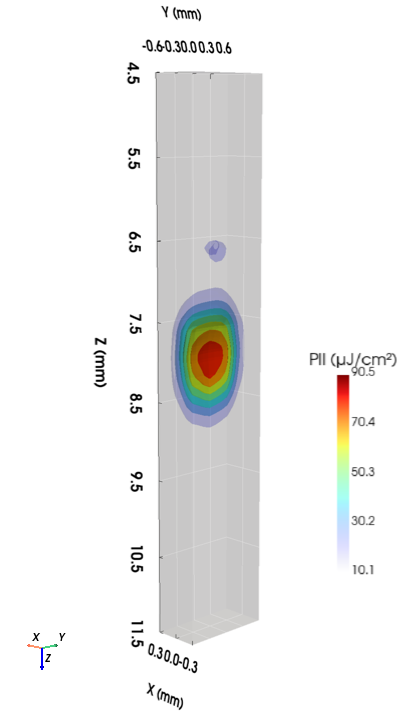

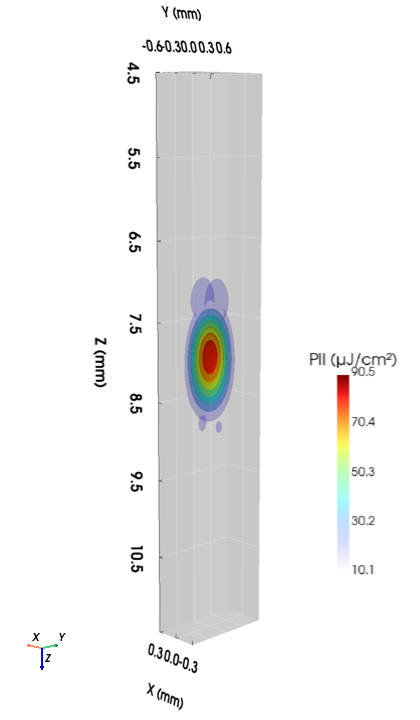

Plotting F/D = 1.5 : real and simulated


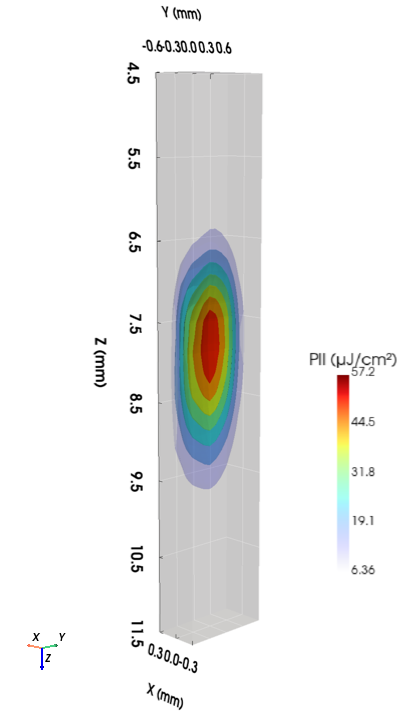

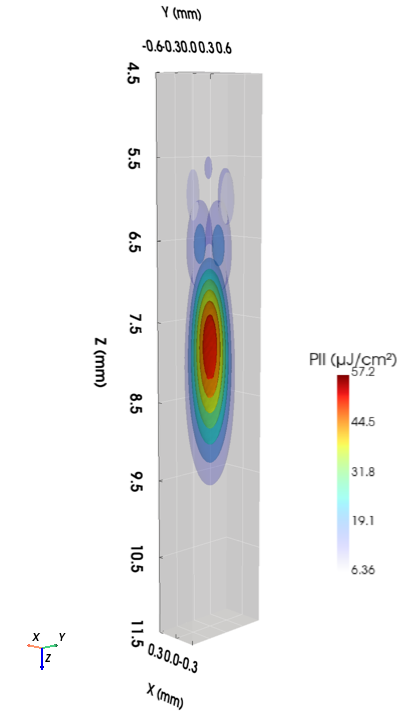

Plotting F/D = 2 : real and simulated


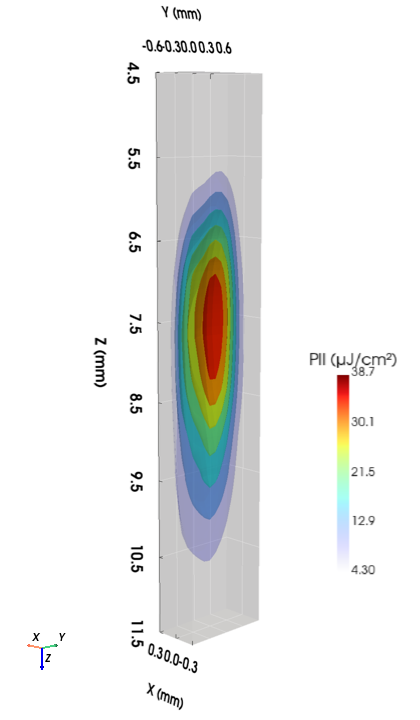

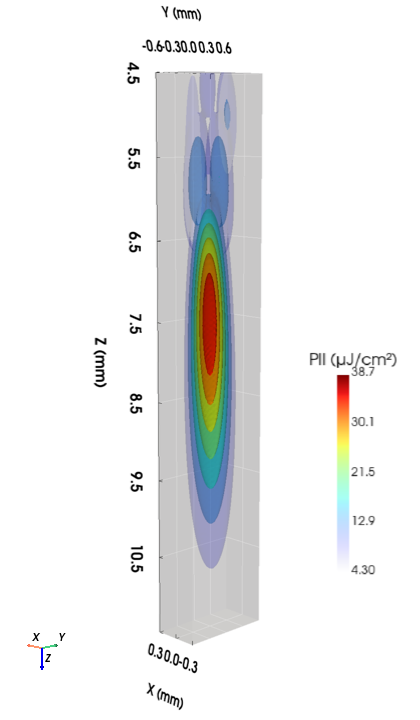

In [55]:
print('Plotting F/D = 1 : real and simulated')
plot_volume(real_x1, real_y1, real_z1, real_FD1, image_name=folder+'FD1_real.png') #, image_name = 'FD1_real.png')
plot_volume(simu_x1, simu_y1, simu_z1, simu_FD1, image_name=folder+f'FD1_simu{method}.png') #, image_name = 'FD1_real.png')

print('Plotting F/D = 1.5 : real and simulated')
plot_volume(real_x15, real_y15, real_z15, real_FD15, image_name=folder+'FD15_real.png') #, image_name = 'FD1_real.png')
plot_volume(simu_x15, simu_y15, simu_z15, simu_FD15, image_name=folder+f'FD15_simu{method}.png') #, image_name = 'FD1_real.png')

print('Plotting F/D = 2 : real and simulated')
plot_volume(real_x2, real_y2, real_z2, real_FD2, image_name=folder+'FD2_real.png') #, image_name = 'FD1_real.png')
plot_volume(simu_x2, simu_y2, simu_z2, simu_FD2, image_name=folder+f'FD2_simu{method}.png') #, image_name = 'FD1_real.png')

### 5.1.4. 2D Visualization of pressure field

In [56]:
def plot_comparison_slices(x,y,z, field1, field2, *, figsize = (10,8), xslice = 0, yslice = 0, zslice = 8, interpolation = 'bilinear', cmap = 'jet'):
    
    slice_idx = np.argmin(np.abs(x - xslice))
    slice_idy = np.argmin(np.abs(y - yslice))
    slice_idz = np.argmin(np.abs(z - zslice))

    print(f"slice_idx: {slice_idx}, slice_idy: {slice_idy}, slice_idz: {slice_idz}")
    print(f"xslice (mm): {x[slice_idx]:.2f}, yslice (mm): {y[slice_idy]:.2f}, zslice (mm): {z[slice_idz]:.2f}")

    vmin = min(field1.min(), field2.min())
    vmax = max(field1.max(), field2.max())

    # Make a grid row 2 and 5 columns
    # first column plane xz field1
    # second column plane xz field2
    # first row third column plane yx field1
    # second row third column plane yx field2
    # fourth column plane zy field1
    # fifth column plane zy field2

    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(2, 6, figure=fig, width_ratios=[0.5, 0.5, 1, 0.8, 0.8, 0.05])

    # a) XZ slices planes
    ax_xz_1 = fig.add_subplot(gs[:, 0])

    im = ax_xz_1.imshow(field1[:, slice_idy, :].T, extent=[x.min(), x.max(), z.max(), z.min()], cmap=cmap, interpolation=interpolation, vmin=vmin, vmax=vmax)
    ax_xz_1.set_xlabel('x (mm)')
    ax_xz_1.set_ylabel('z (mm)')
    ax_xz_1.set_xticks([x.min(), 0, x.max()])
    ax_xz_1.set_xticklabels([f"{x.min():.1f}", "0", f"{x.max():.1f}"])
    ax_xz_1.set_title('a)')
    
    ax_xz_2 = fig.add_subplot(gs[:, 1])
    ax_xz_2.imshow(field2[:, slice_idy, :].T, extent=[x.min(), x.max(), z.max(), z.min()], cmap=cmap, interpolation=interpolation, vmin=vmin, vmax=vmax)
    ax_xz_2.set_xlabel('x (mm)')
    ax_xz_2.set_ylabel('z (mm)')
    ax_xz_2.set_xticks([x.min(), 0, x.max()])
    ax_xz_2.set_xticklabels([f"{x.min():.1f}", "0", f"{x.max():.1f}"])
    ax_xz_2.set_title('b)')

    # b) YX slices planes
    ax_yx_1 = fig.add_subplot(gs[0, 2])
    im = ax_yx_1.imshow(field1[:, :, slice_idz].T, extent=[x.min(), x.max(), y.max(), y.min()], cmap=cmap, interpolation=interpolation, vmin=vmin, vmax=vmax)
    ax_yx_1.set_xlabel('x (mm)')
    ax_yx_1.set_ylabel('y (mm)')
    ax_yx_1.set_title('c)')

    ax_yx_2 = fig.add_subplot(gs[1, 2])
    ax_yx_2.imshow(field2[:, :, slice_idz].T, extent=[x.min(), x.max(), y.max(), y.min()], cmap=cmap, interpolation=interpolation, vmin=vmin, vmax=vmax)
    ax_yx_2.set_xlabel('x (mm)')
    ax_yx_2.set_ylabel('y (mm)')
    ax_yx_2.set_title('d)')

    # c) ZY slices planes
    ax_zy_1 = fig.add_subplot(gs[:, 3])
    im = ax_zy_1.imshow(field1[slice_idx, :, :].T, extent=[y.min(), y.max(), z.max(), z.min()], cmap=cmap, interpolation=interpolation, vmin=vmin, vmax=vmax)
    ax_zy_1.set_xlabel('y (mm)')
    ax_zy_1.set_ylabel('z (mm)')
    ax_zy_1.set_title('e)')
    
    ax_zy_2 = fig.add_subplot(gs[:, 4])
    ax_zy_2.imshow(field2[slice_idx, :, :].T, extent=[y.min(), y.max(), z.max(), z.min()], cmap=cmap, interpolation=interpolation, vmin=vmin, vmax=vmax)
    ax_zy_2.set_xlabel('y (mm)')
    ax_zy_2.set_ylabel('z (mm)')
    ax_zy_2.set_title('f)')

    # Add colorbar to the right of the last column
    # Make it span both rows
    cax = fig.add_subplot(gs[:, 5])
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label('PII₀ (μJ/cm²)')
    plt.tight_layout()
    return fig                     

def plot_comparison_contours(x, y, z, field1, field2, *, figsize=(10, 8), xslice=0, yslice=0, zslice=8, cmap='jet', levels=15):
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    import numpy as np

    slice_idx = np.argmin(np.abs(x - xslice))
    slice_idy = np.argmin(np.abs(y - yslice))
    slice_idz = np.argmin(np.abs(z - zslice))

    print(f"slice_idx: {slice_idx}, slice_idy: {slice_idy}, slice_idz: {slice_idz}")
    print(f"xslice (mm): {x[slice_idx]:.2f}, yslice (mm): {y[slice_idy]:.2f}, zslice (mm): {z[slice_idz]:.2f}")

    vmin = min(field1.min(), field2.min())
    vmax = max(field1.max(), field2.max())

    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(2, 6, figure=fig, width_ratios=[0.5, 0.5, 1, 0.8, 0.8, 0.05])

    # a) XZ slices planes
    ax_xz_1 = fig.add_subplot(gs[:, 0])
    X, Z = np.meshgrid(x, z)
    cf1 = ax_xz_1.contourf(x, z, field1[:, slice_idy, :].T, levels=levels, cmap=cmap, vmin=vmin, vmax=vmax)
    ax_xz_1.set_xlabel('x (mm)')
    ax_xz_1.set_ylabel('z (mm)')
    ax_xz_1.set_xticks([x.min(), 0, x.max()])
    ax_xz_1.set_xticklabels([f"{x.min():.2f}", "0", f"{x.max():.2f}"])
    ax_xz_1.invert_yaxis()
    ax_xz_1.set_title('a)')

    ax_xz_2 = fig.add_subplot(gs[:, 1])
    cf2 = ax_xz_2.contourf(x, z, field2[:, slice_idy, :].T, levels=levels, cmap=cmap, vmin=vmin, vmax=vmax)
    ax_xz_2.set_xlabel('x (mm)')
    ax_xz_2.set_ylabel('z (mm)')
    ax_xz_2.set_xticks([x.min(), 0, x.max()])
    ax_xz_2.set_xticklabels([f"{x.min():.2f}", "0", f"{x.max():.2f}"])
    ax_xz_2.invert_yaxis()
    ax_xz_2.set_title('b)')

    # b) YX slices planes
    ax_yx_1 = fig.add_subplot(gs[0, 2])
    cf3 = ax_yx_1.contourf(x, y, field1[:, :, slice_idz].T, levels=levels, cmap=cmap, vmin=vmin, vmax=vmax)
    ax_yx_1.set_xlabel('x (mm)')
    ax_yx_1.set_ylabel('y (mm)')
    ax_yx_1.invert_yaxis()
    ax_yx_1.set_title('c)')

    ax_yx_2 = fig.add_subplot(gs[1, 2])
    cf4 = ax_yx_2.contourf(x, y, field2[:, :, slice_idz].T, levels=levels, cmap=cmap, vmin=vmin, vmax=vmax)
    ax_yx_2.set_xlabel('x (mm)')
    ax_yx_2.set_ylabel('y (mm)')
    ax_yx_2.invert_yaxis()
    ax_yx_2.set_title('d)')

    # c) ZY slices planes
    ax_zy_1 = fig.add_subplot(gs[:, 3])
    cf5 = ax_zy_1.contourf(y, z, field1[slice_idx, :, :].T, levels=levels, cmap=cmap, vmin=vmin, vmax=vmax)
    ax_zy_1.set_xlabel('y (mm)')
    ax_zy_1.set_ylabel('z (mm)')
    ax_zy_1.invert_yaxis()
    ax_zy_1.set_title('e)')

    ax_zy_2 = fig.add_subplot(gs[:, 4])
    cf6 = ax_zy_2.contourf(y, z, field2[slice_idx, :, :].T, levels=levels, cmap=cmap, vmin=vmin, vmax=vmax)
    ax_zy_2.set_xlabel('y (mm)')
    ax_zy_2.set_ylabel('z (mm)')
    ax_zy_2.invert_yaxis()
    ax_zy_2.set_title('f)')

    # Add colorbar to the right of the last column (use the last contourf for colorbar)
    cax = fig.add_subplot(gs[:, 5])
    cbar = fig.colorbar(cf6, cax=cax)
    cbar.set_label('PII₀ (μJ/cm²)')
    plt.tight_layout()
    return fig



slice_idx: 34, slice_idy: 64, slice_idz: 99
xslice (mm): -0.00, yslice (mm): -0.00, zslice (mm): 7.98
slice_idx: 34, slice_idy: 64, slice_idz: 119
xslice (mm): -0.00, yslice (mm): -0.00, zslice (mm): 7.99
slice_idx: 34, slice_idy: 64, slice_idz: 99
xslice (mm): -0.00, yslice (mm): -0.00, zslice (mm): 7.98


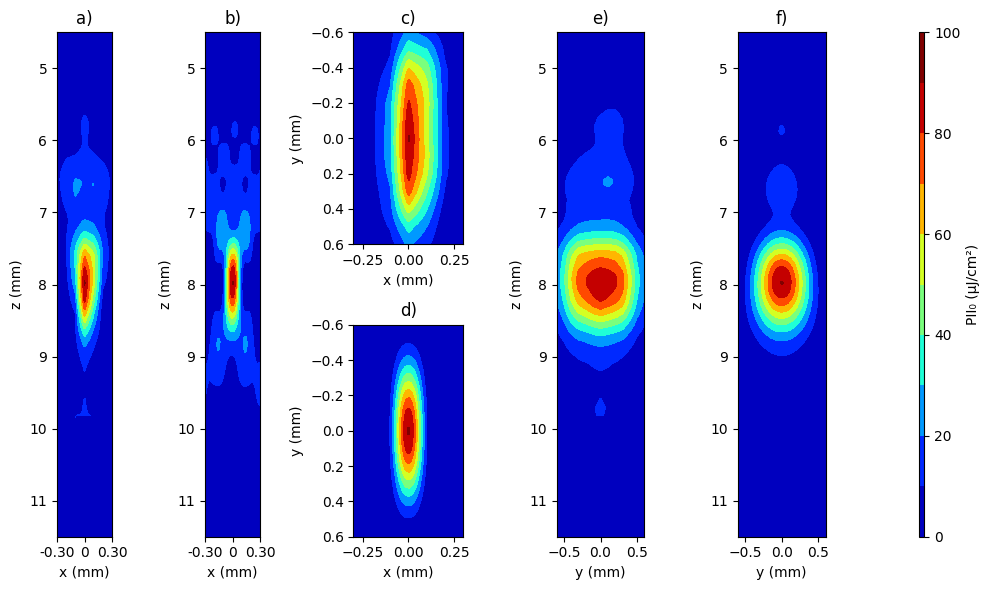

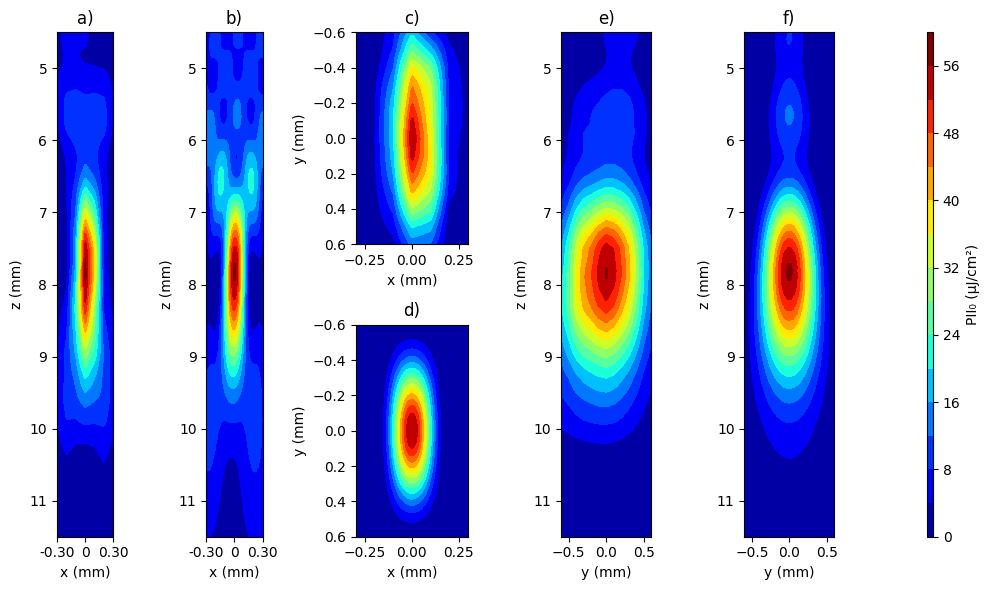

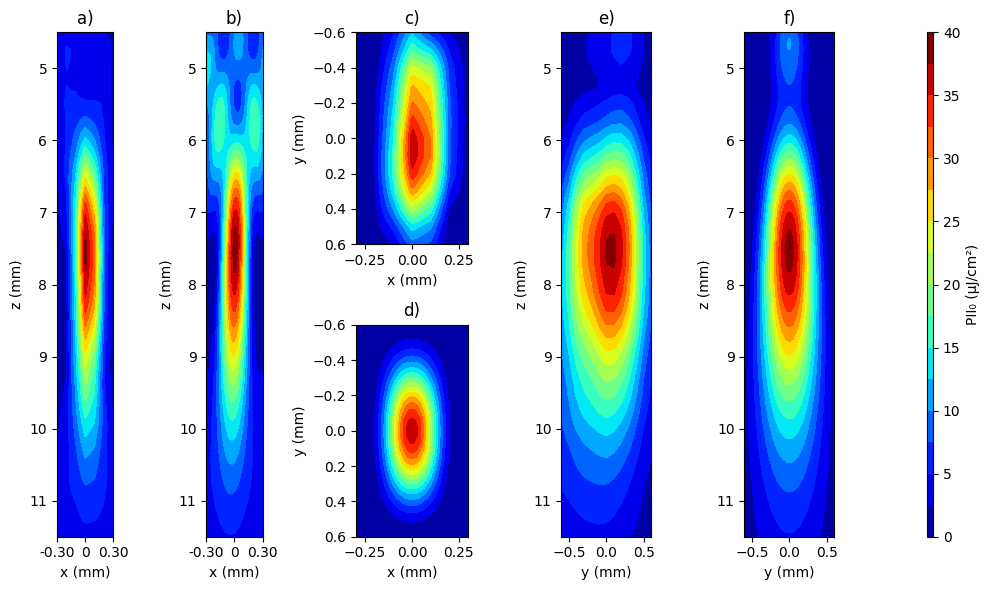

In [57]:
fig_cFD1 = plot_comparison_contours(real_x1, real_y1, real_z1, real_FD1, simu_FD1, figsize = (10,6), levels = 10)
fig_cFD15 = plot_comparison_contours(real_x15, real_y15, real_z15, real_FD15, simu_FD15, figsize = (10,6))
fig_cFD2 = plot_comparison_contours(real_x2, real_y2, real_z2, real_FD2, simu_FD2, figsize = (10,6))

slice_idx: 34, slice_idy: 64, slice_idz: 99
xslice (mm): -0.00, yslice (mm): -0.00, zslice (mm): 7.98
slice_idx: 34, slice_idy: 64, slice_idz: 119
xslice (mm): -0.00, yslice (mm): -0.00, zslice (mm): 7.99
slice_idx: 34, slice_idy: 64, slice_idz: 99
xslice (mm): -0.00, yslice (mm): -0.00, zslice (mm): 7.98


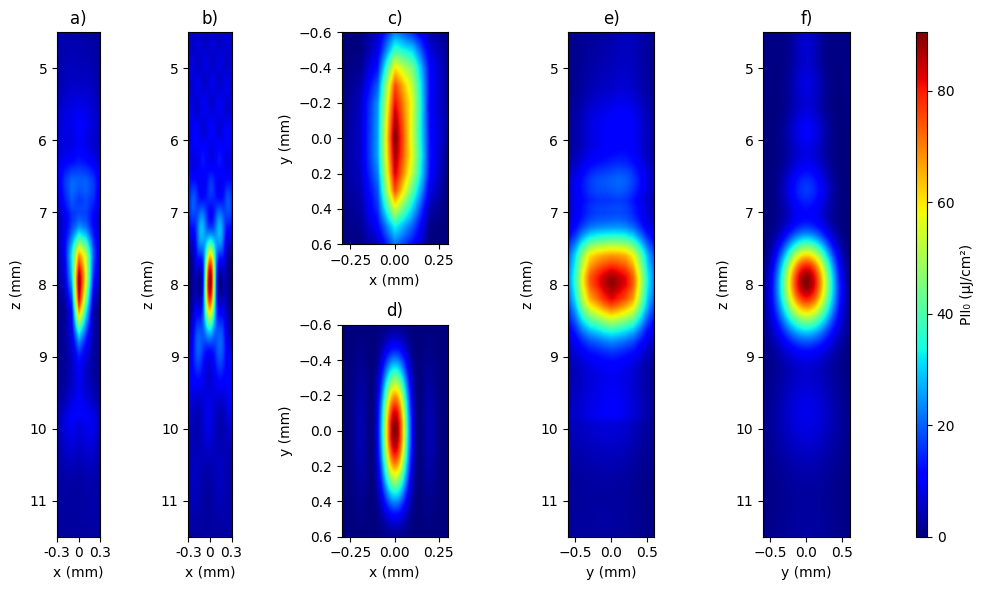

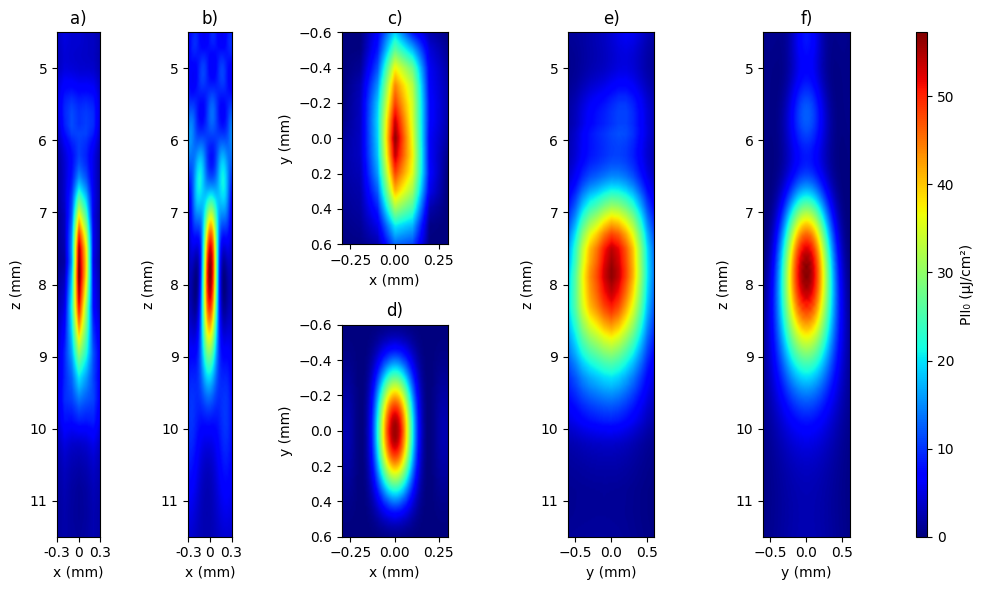

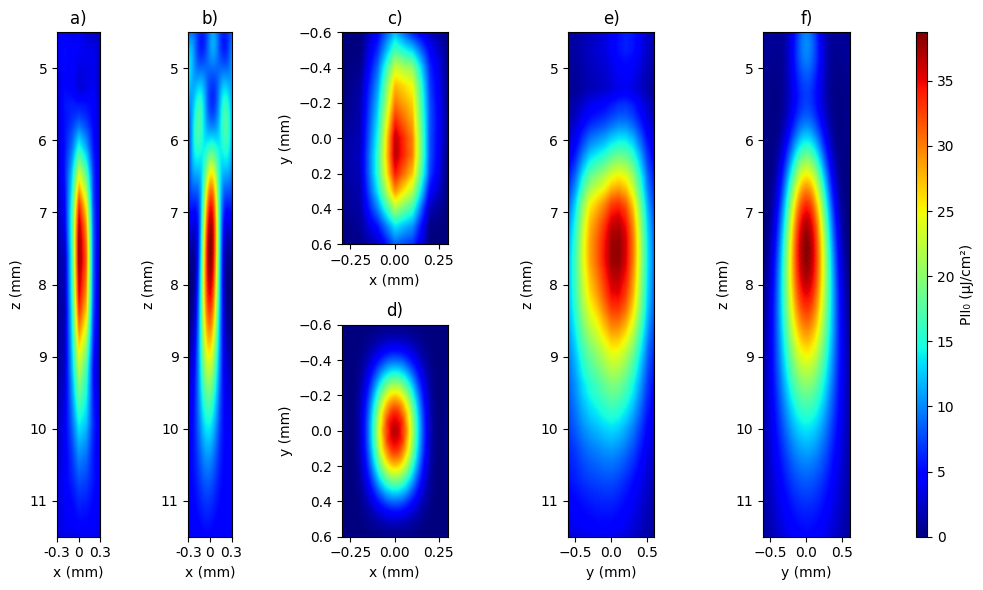

In [58]:
fig_FD1 = plot_comparison_slices(real_x1, real_y1, real_z1, real_FD1, simu_FD1, figsize = (10,6))
fig_FD15 = plot_comparison_slices(real_x15, real_y15, real_z15, real_FD15, simu_FD15, figsize = (10,6))
fig_FD2 = plot_comparison_slices(real_x2, real_y2, real_z2, real_FD2, simu_FD2, figsize = (10,6))

In [59]:
fig_FD1.savefig(folder+f'Comparison_FD1{method}.png', dpi=300)
fig_FD15.savefig(folder+f'Comparison_FD15{method}.png', dpi=300)
fig_FD2.savefig(folder+f'Comparison_FD2{method}.png', dpi=300)
fig_cFD1.savefig(folder+f'Comparison_contour_FD1{method}.png', dpi=300)
fig_cFD15.savefig(folder+f'Comparison_contour_FD15{method}.png', dpi=300)
fig_cFD2.savefig(folder+f'Comparison_contour_FD2{method}.png', dpi=300)

# 5. Perfomance analysis

In [60]:
print(linear_field.sir_running_time_log)
print(matrix_field.sir_running_time_log)

[4.655748605728149, 0.5619022846221924, 0.4365837574005127, 4.263693332672119, 0.022688627243041992, 0.0, 0.0, 0.002253293991088867, 0.0, 0.0]
[6.852349281311035, 7.018504619598389, 3.605241298675537, 3.582780122756958, 0.18001699447631836, 0.0, 0.0, 0.0, 0.0, 0.0]
